<a href="https://colab.research.google.com/github/mvaraujo1977/TechCahllenge_Tireoide/blob/Nirton_Afonso/notebooks/01_classificacao_tireoide.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação de Hipotireoidismo com Machine Learning

## Tech Challenge - Fase 1 | IA para Devs

Este projeto apresenta uma solução inicial de Machine Learning aplicada à análise de dados médicos tabulares, com foco na classificação de registros clínicos relacionados à tireoide. A proposta consiste em estimar, a partir de variáveis demográficas, clínicas e laboratoriais, se um registro apresenta indicação de **hipotireoidismo** ou se pertence à classe **negativa**.

O problema foi estruturado como uma tarefa de classificação binária supervisionada. Esse tipo de abordagem pode contribuir para etapas de triagem, priorização de análise e apoio à organização do fluxo clínico, especialmente em cenários com grande volume de exames e dados estruturados.

A solução desenvolvida tem caráter acadêmico e experimental. Os resultados obtidos devem ser interpretados como apoio analítico à decisão médica, sem substituir avaliação clínica, anamnese, exame físico, protocolos institucionais ou julgamento profissional. A decisão final sobre diagnóstico e conduta permanece sempre sob responsabilidade de profissionais da saúde.

## 1. Preparação do Ambiente

A execução foi pensada para o Google Colab, ambiente no qual o dataset será baixado diretamente do repositório GitHub para uma pasta local da sessão. A célula abaixo permanece como recurso opcional para instalação de dependências caso o ambiente não contenha todos os pacotes necessários.

In [1]:
# Célula opcional para Google Colab.
# Execute somente se alguma biblioteca não estiver disponível no ambiente.
#
# !pip install -q pandas numpy matplotlib seaborn scikit-learn joblib shap

## 2. Importação das Bibliotecas

Foram utilizadas bibliotecas consolidadas do ecossistema Python para análise de dados, visualização, modelagem supervisionada, avaliação de desempenho e persistência do modelo. O parâmetro `RANDOM_STATE` foi definido para favorecer reprodutibilidade nas divisões amostrais e nos algoritmos estocásticos.

In [2]:
import sys
import urllib.request
import warnings
from pathlib import Path
from IPython.display import display

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, auc, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score, roc_curve
)
from sklearn.model_selection import learning_curve, train_test_split, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

RANDOM_STATE = 42
TARGET_COLUMN = "target"
POSITIVE_LABEL = "hypothyroid"
NEGATIVE_LABEL = "negative"

## 3. Fonte de Dados e Diretórios do Projeto

O arquivo `hypothyroid_final.csv` será obtido diretamente do GitHub e armazenado na estrutura `/content/TechCahllenge_Tireoide/dataset/` quando o notebook estiver no Google Colab. Em execução local, o código mantém compatibilidade com o arquivo já presente no repositório.

In [3]:
GITHUB_DATA_URL = (
    "https://raw.githubusercontent.com/"
    "mvaraujo1977/TechCahllenge_Tireoide/"
    "Nirton_Afonso/dataset/hypothyroid_final.csv"
)

RUNNING_IN_COLAB = "google.colab" in sys.modules

if RUNNING_IN_COLAB:
    PROJECT_ROOT = Path("/content/TechCahllenge_Tireoide")
    DATA_DIR = PROJECT_ROOT / "dataset"
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    DATA_PATH = DATA_DIR / "hypothyroid_final.csv"

    print("Ambiente Google Colab detectado.")
    print(f"Baixando dataset do GitHub para: {DATA_PATH}")
    urllib.request.urlretrieve(GITHUB_DATA_URL, DATA_PATH)
else:
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name.lower() == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

    DATA_PATH = PROJECT_ROOT / "dataset" / "hypothyroid_final.csv"
    if not DATA_PATH.exists():
        DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
        print("Dataset local não encontrado. Baixando do GitHub para a pasta dataset/ do projeto.")
        urllib.request.urlretrieve(GITHUB_DATA_URL, DATA_PATH)

MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Fonte GitHub: {GITHUB_DATA_URL}")
print(f"Dataset em uso: {DATA_PATH.resolve()}")
print(f"Diretório de modelos: {MODELS_DIR.resolve()}")
print(f"Diretório de figuras: {FIGURES_DIR.resolve()}")

Ambiente Google Colab detectado.
Baixando dataset do GitHub para: /content/TechCahllenge_Tireoide/dataset/hypothyroid_final.csv
Fonte GitHub: https://raw.githubusercontent.com/mvaraujo1977/TechCahllenge_Tireoide/Nirton_Afonso/dataset/hypothyroid_final.csv
Dataset em uso: /content/TechCahllenge_Tireoide/dataset/hypothyroid_final.csv
Diretório de modelos: /content/TechCahllenge_Tireoide/models
Diretório de figuras: /content/TechCahllenge_Tireoide/reports/figures


## 4. Carregamento do Dataset

A base utilizada corresponde à versão tabular já consolidada do conjunto de dados de hipotireoidismo. A variável `target` representa a classe de interesse e será utilizada como variável-alvo do problema de classificação.

In [4]:
dados = pd.read_csv(DATA_PATH, na_values=["?", "", "NA", "NaN"])

print("Primeiras linhas:")
display(dados.head())
print(f"Dimensão: {dados.shape[0]} linhas e {dados.shape[1]} colunas")
print("\nColunas:")
print(list(dados.columns))

Primeiras linhas:


,target,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,thyroid_surgery,query_hypothyroid,query_hyperthyroid,pregnant,...,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG
0,hypothyroid,72.0,M,f,f,f,f,f,f,f,...,y,0.6,y,15.0,y,1.48,y,10.0,n,NaN
1,hypothyroid,15.0,F,t,f,f,f,f,f,f,...,y,1.7,y,19.0,y,1.13,y,17.0,n,NaN
2,hypothyroid,24.0,M,f,f,f,f,f,f,f,...,y,0.2,y,4.0,y,1.00,y,0.0,n,NaN
3,hypothyroid,24.0,F,f,f,f,f,f,f,f,...,y,0.4,y,6.0,y,1.04,y,6.0,n,NaN
4,hypothyroid,77.0,M,f,f,f,f,f,f,f,...,y,1.2,y,57.0,y,1.28,y,44.0,n,NaN


Dimensão: 3163 linhas e 26 colunas

Colunas:
['target', 'age', 'sex', 'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_medication', 'thyroid_surgery', 'query_hypothyroid', 'query_hyperthyroid', 'pregnant', 'sick', 'tumor', 'lithium', 'goitre', 'TSH_measured', 'TSH', 'T3_measured', 'T3', 'TT4_measured', 'TT4', 'T4U_measured', 'T4U', 'FTI_measured', 'FTI', 'TBG_measured', 'TBG']


In [5]:
print("Informações gerais:")
dados.info()

print("\nEstatísticas numéricas:")
display(dados.describe().T)

print("\nEstatísticas categóricas:")
display(dados.describe(include="object").T)

Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3163 entries, 0 to 3162
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   target                     3163 non-null   object 
 1   age                        2717 non-null   float64
 2   sex                        3090 non-null   object 
 3   on_thyroxine               3163 non-null   object 
 4   query_on_thyroxine         3163 non-null   object 
 5   on_antithyroid_medication  3163 non-null   object 
 6   thyroid_surgery            3163 non-null   object 
 7   query_hypothyroid          3163 non-null   object 
 8   query_hyperthyroid         3163 non-null   object 
 9   pregnant                   3163 non-null   object 
 10  sick                       3163 non-null   object 
 11  tumor                      3163 non-null   object 
 12  lithium                    3163 non-null   object 
 13  goitre                     3

,count,mean,std,min,25%,50%,75%,max
age,2717.0,51.154214,19.294405,1.0,35.00,54.00,67.000,98.00
TSH,2695.0,5.923180,23.899467,0.0,0.00,0.70,2.300,530.00
T3,2468.0,1.939749,0.996773,0.0,1.40,1.80,2.300,10.20
TT4,2914.0,108.850000,45.485419,2.0,83.00,104.00,128.000,450.00
T4U,2915.0,0.978199,0.226580,0.0,0.85,0.96,1.065,2.21
FTI,2916.0,115.397771,60.239572,0.0,91.00,107.00,129.000,881.00
TBG,260.0,31.283077,19.224659,0.0,21.00,28.00,34.000,122.00



Estatísticas categóricas:


,count,unique,top,freq
target,3163,2,negative,3012
sex,3090,2,F,2182
on_thyroxine,3163,2,f,2702
query_on_thyroxine,3163,2,f,3108
on_antithyroid_medication,3163,2,f,3121
thyroid_surgery,3163,2,f,3059
query_hypothyroid,3163,2,f,2922
query_hyperthyroid,3163,2,f,2920
pregnant,3163,2,f,3100
sick,3163,2,f,3064


A inspeção inicial evidencia a presença de variáveis contínuas, como idade e exames laboratoriais, e variáveis categóricas associadas a características clínicas, uso de medicamentos, sintomas e indicação de exames medidos. Essa composição reforça a adequação de pipelines de pré-processamento distintos para atributos numéricos e categóricos.

## 5. Análise Exploratória dos Dados (EDA)

A análise exploratória foi conduzida para caracterizar a qualidade, a estrutura e os padrões gerais da base. Em dados médicos, essa etapa é particularmente relevante, pois ausência de exames, desbalanceamento de classes e valores extremos podem refletir tanto limitações operacionais da coleta quanto sinais clínicos relevantes.

Linhas: 3163
Colunas: 26


,tipo,quantidade
0,object,19
1,float64,7


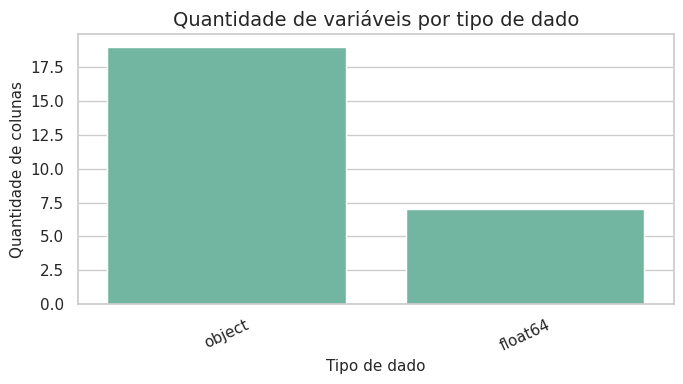

In [6]:
linhas, colunas = dados.shape
print(f"Linhas: {linhas}")
print(f"Colunas: {colunas}")

resumo_tipos = dados.dtypes.value_counts().rename_axis("tipo").reset_index(name="quantidade")
display(resumo_tipos)

plt.figure(figsize=(7, 4))
sns.barplot(data=resumo_tipos, x="tipo", y="quantidade")
plt.title("Quantidade de variáveis por tipo de dado")
plt.xlabel("Tipo de dado")
plt.ylabel("Quantidade de colunas")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

A distribuição dos tipos de dados confirma a presença de variáveis numéricas e categóricas. Essa distinção será preservada no pré-processamento, permitindo imputação, padronização e codificação de forma apropriada para cada grupo de atributos.

,ausentes,percentual
TBG,2903,91.78
T3,695,21.97
TSH,468,14.80
age,446,14.10
TT4,249,7.87
T4U,248,7.84
FTI,247,7.81
sex,73,2.31


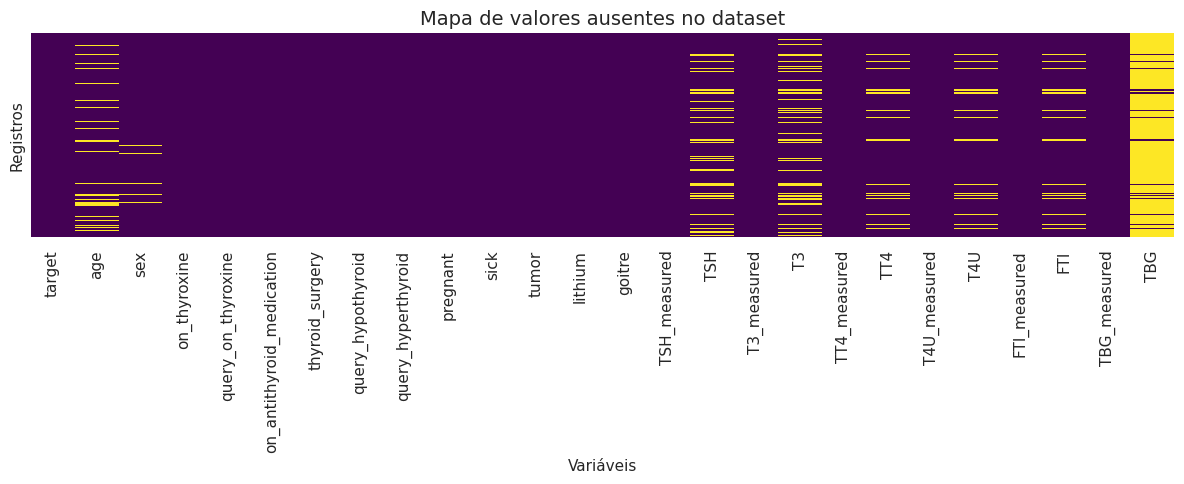

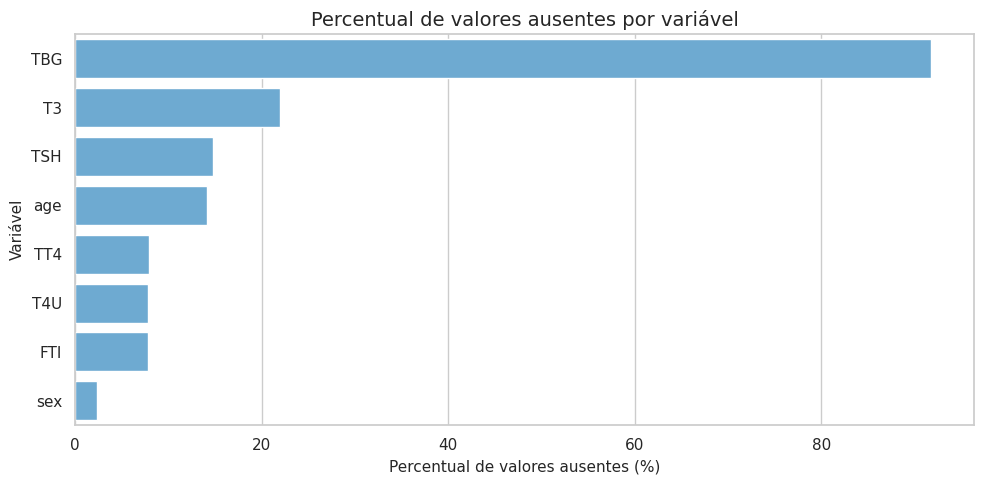

In [7]:
missing_count = dados.isna().sum().sort_values(ascending=False)
missing_percent = (missing_count / len(dados) * 100).round(2)
missing_table = pd.DataFrame({"ausentes": missing_count, "percentual": missing_percent})
missing_table = missing_table[missing_table["ausentes"] > 0]
display(missing_table)

plt.figure(figsize=(12, 5))
sns.heatmap(dados.isna(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Mapa de valores ausentes no dataset")
plt.xlabel("Variáveis")
plt.ylabel("Registros")
plt.tight_layout()
plt.show()

if not missing_table.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=missing_table.reset_index(), x="percentual", y="index", color="#5DADE2")
    plt.title("Percentual de valores ausentes por variável")
    plt.xlabel("Percentual de valores ausentes (%)")
    plt.ylabel("Variável")
    plt.tight_layout()
    plt.show()

Os valores ausentes concentram-se principalmente em variáveis laboratoriais. Esse padrão é compatível com bases clínicas, nas quais nem todos os exames são solicitados para todos os pacientes. Para evitar vazamento de informação, a imputação será ajustada exclusivamente com os dados de treino dentro do pipeline.

In [8]:
duplicados = dados.duplicated().sum()
print(f"Registros duplicados encontrados: {duplicados}")
print(f"Percentual de duplicados: {duplicados / len(dados) * 100:.2f}%")

Registros duplicados encontrados: 77
Percentual de duplicados: 2.43%


A presença de registros duplicados pode introduzir viés na avaliação do modelo, sobretudo se uma mesma observação aparecer em subconjuntos diferentes. Por esse motivo, a duplicidade será tratada explicitamente na etapa de limpeza.

,quantidade,percentual
target,,
negative,3012,95.23
hypothyroid,151,4.77


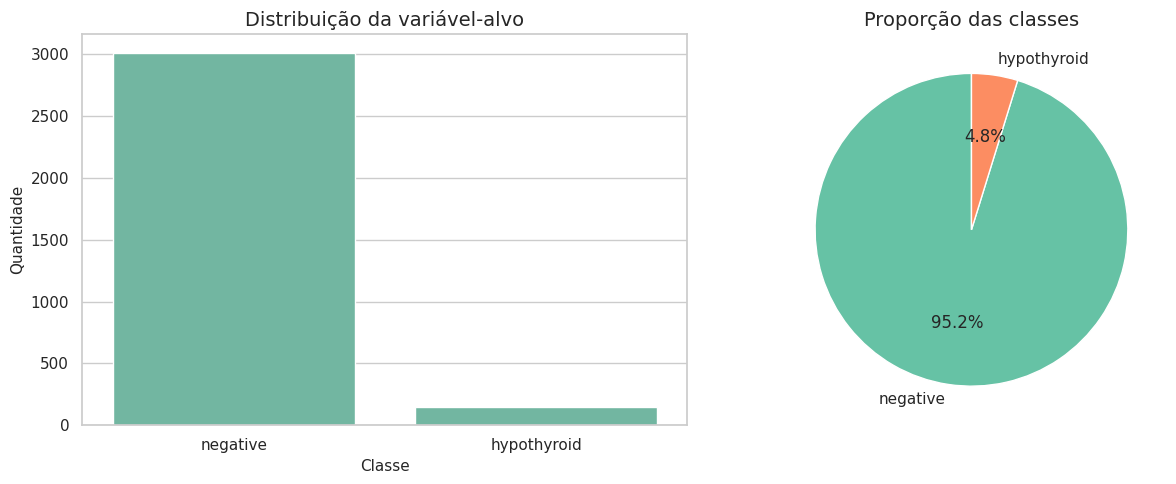

In [9]:
target_counts = dados[TARGET_COLUMN].value_counts()
target_percent = dados[TARGET_COLUMN].value_counts(normalize=True).mul(100).round(2)
target_summary = pd.DataFrame({"quantidade": target_counts, "percentual": target_percent})
display(target_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=dados, x=TARGET_COLUMN, order=target_counts.index, ax=axes[0])
axes[0].set_title("Distribuição da variável-alvo")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Quantidade")
axes[1].pie(target_counts.values, labels=target_counts.index, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Proporção das classes")
plt.tight_layout()
plt.show()

A variável-alvo apresenta desbalanceamento relevante, com predominância da classe negativa. Esse aspecto influencia a avaliação dos modelos: métricas como recall e F1-score são mais informativas que a acurácia isolada, especialmente quando a classe positiva possui maior importância clínica.

In [10]:
numeric_columns = dados.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = [col for col in dados.columns if col not in numeric_columns and col != TARGET_COLUMN]

print("Variáveis numéricas:", numeric_columns)
print("\nVariáveis categóricas:", categorical_columns)

Variáveis numéricas: ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI', 'TBG']

Variáveis categóricas: ['sex', 'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_medication', 'thyroid_surgery', 'query_hypothyroid', 'query_hyperthyroid', 'pregnant', 'sick', 'tumor', 'lithium', 'goitre', 'TSH_measured', 'T3_measured', 'TT4_measured', 'T4U_measured', 'FTI_measured', 'TBG_measured']


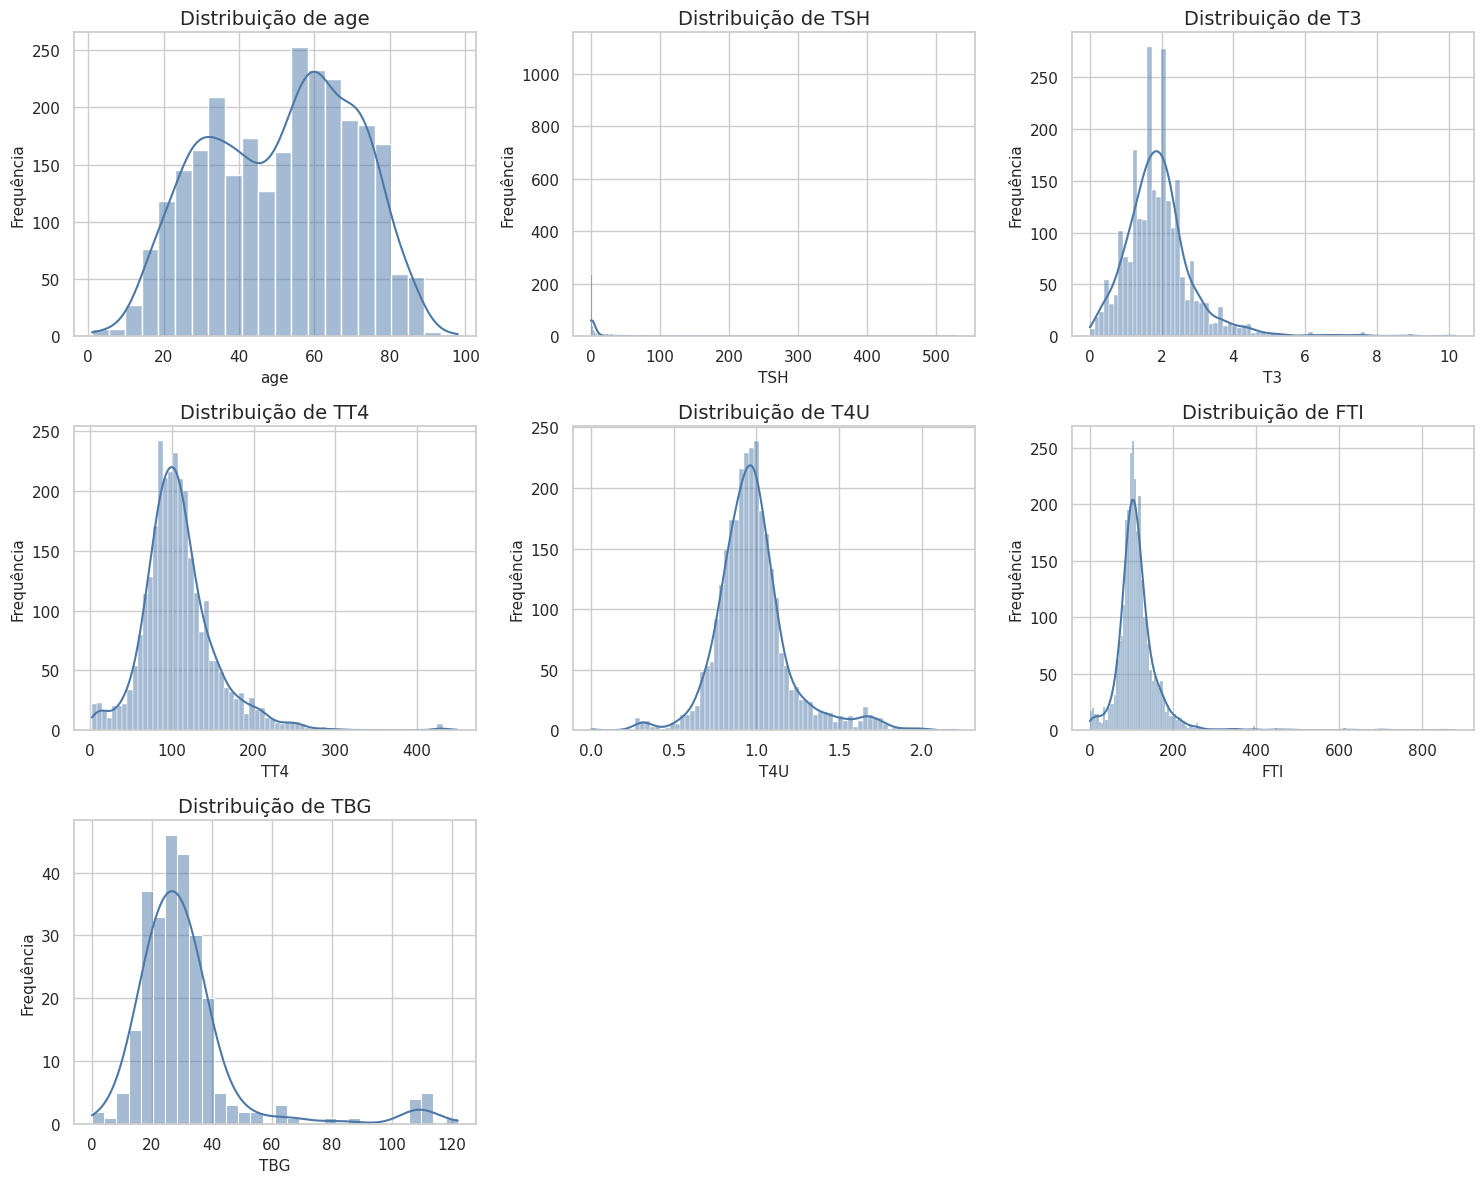

In [11]:
if numeric_columns:
    n_cols = 3
    n_rows = int(np.ceil(len(numeric_columns) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, numeric_columns):
        sns.histplot(data=dados, x=col, kde=True, ax=ax, color="#4C78A8")
        ax.set_title(f"Distribuição de {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Frequência")
    for ax in axes[len(numeric_columns):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

As distribuições numéricas indicam assimetrias e concentrações específicas em variáveis laboratoriais. Em exames clínicos, esse comportamento é esperado e pode refletir tanto padrões populacionais quanto alterações associadas à condição investigada.

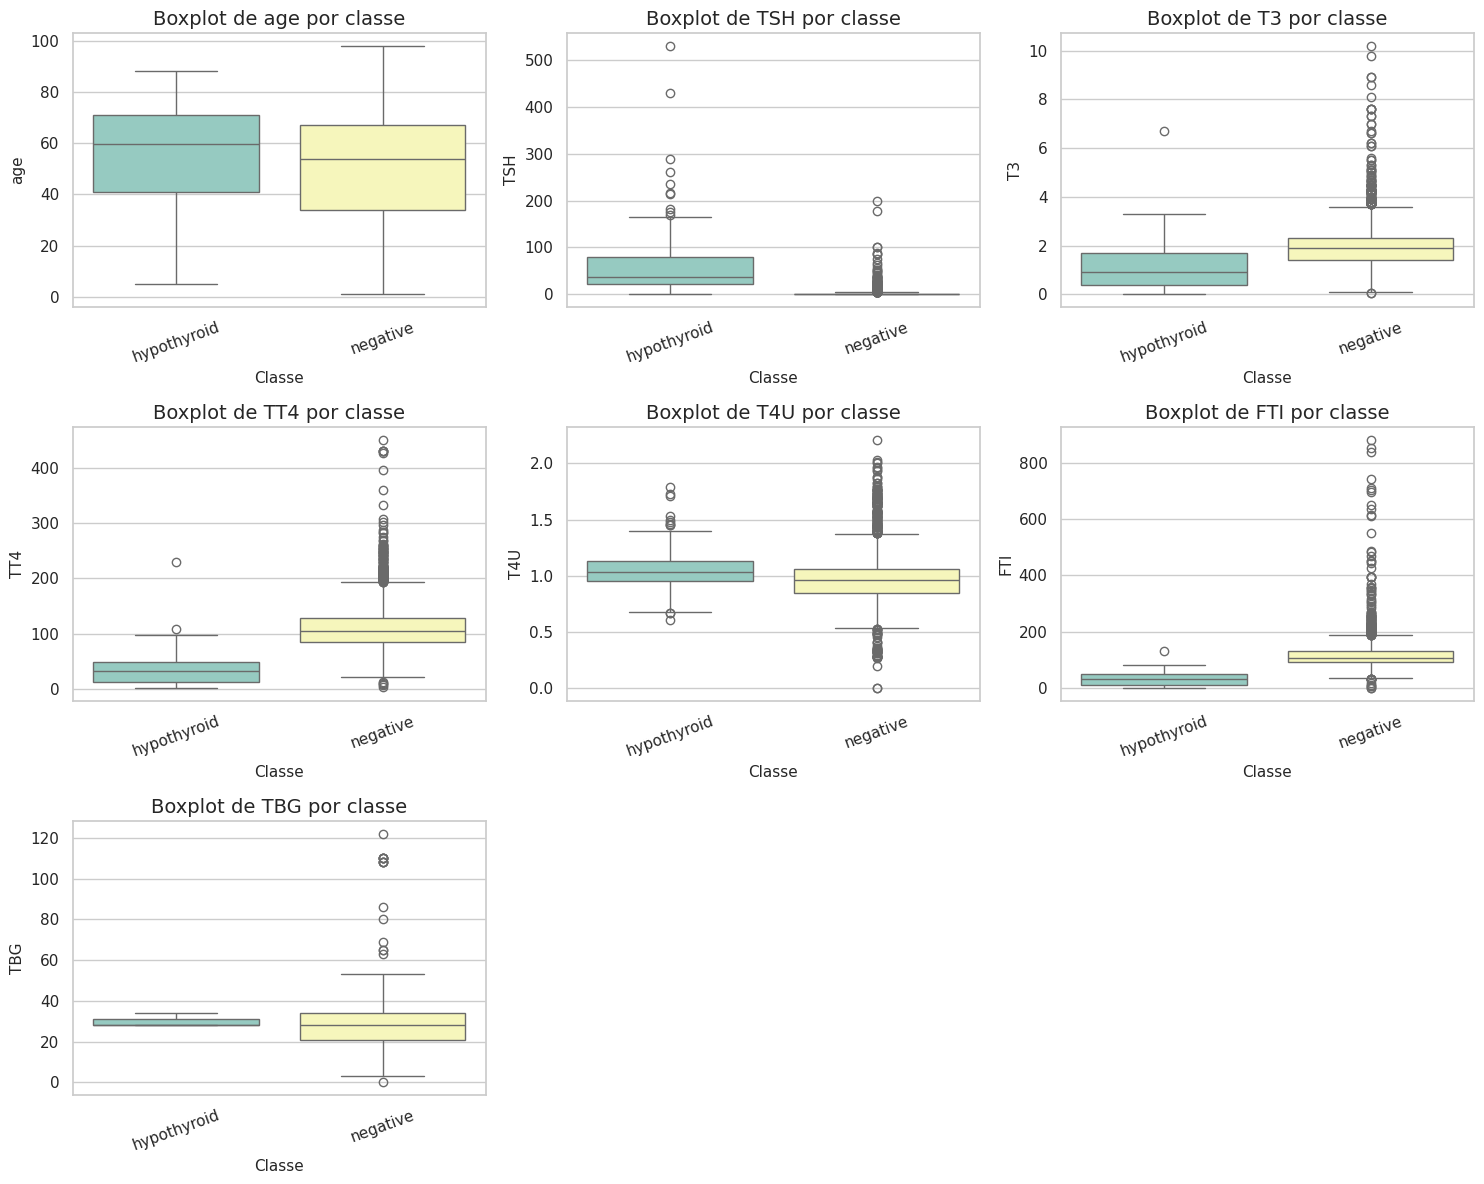

In [12]:
if numeric_columns:
    n_cols = 3
    n_rows = int(np.ceil(len(numeric_columns) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, numeric_columns):
        sns.boxplot(data=dados, x=TARGET_COLUMN, y=col, ax=ax, palette="Set3")
        ax.set_title(f"Boxplot de {col} por classe")
        ax.set_xlabel("Classe")
        ax.set_ylabel(col)
        ax.tick_params(axis="x", rotation=20)
    for ax in axes[len(numeric_columns):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

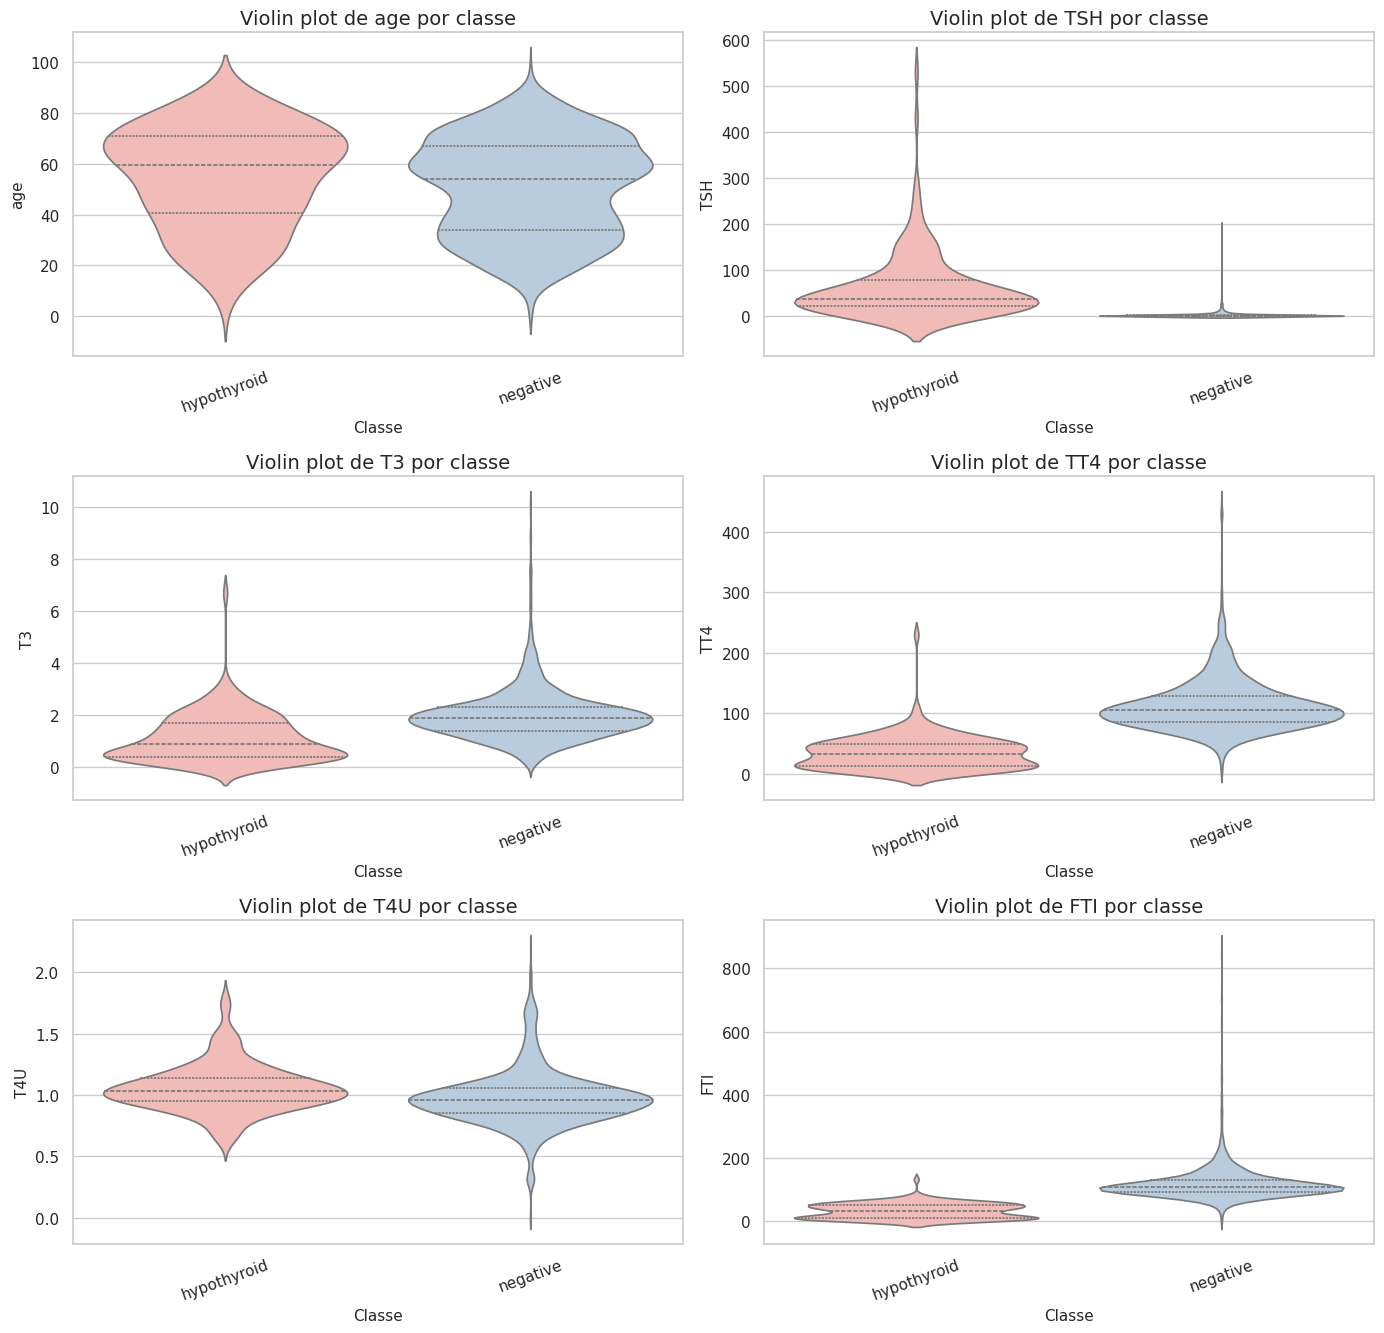

In [13]:
selected_numeric = [col for col in ["age", "TSH", "T3", "TT4", "T4U", "FTI"] if col in dados.columns]

if selected_numeric:
    n_cols = 2
    n_rows = int(np.ceil(len(selected_numeric) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, selected_numeric):
        sns.violinplot(data=dados, x=TARGET_COLUMN, y=col, inner="quartile", ax=ax, palette="Pastel1")
        ax.set_title(f"Violin plot de {col} por classe")
        ax.set_xlabel("Classe")
        ax.set_ylabel(col)
        ax.tick_params(axis="x", rotation=20)
    for ax in axes[len(selected_numeric):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

Os boxplots e violin plots permitem comparar dispersão, mediana e amplitude das variáveis por classe. Valores extremos foram avaliados com cautela, pois podem representar achados laboratoriais clinicamente relevantes e não apenas erros de registro.

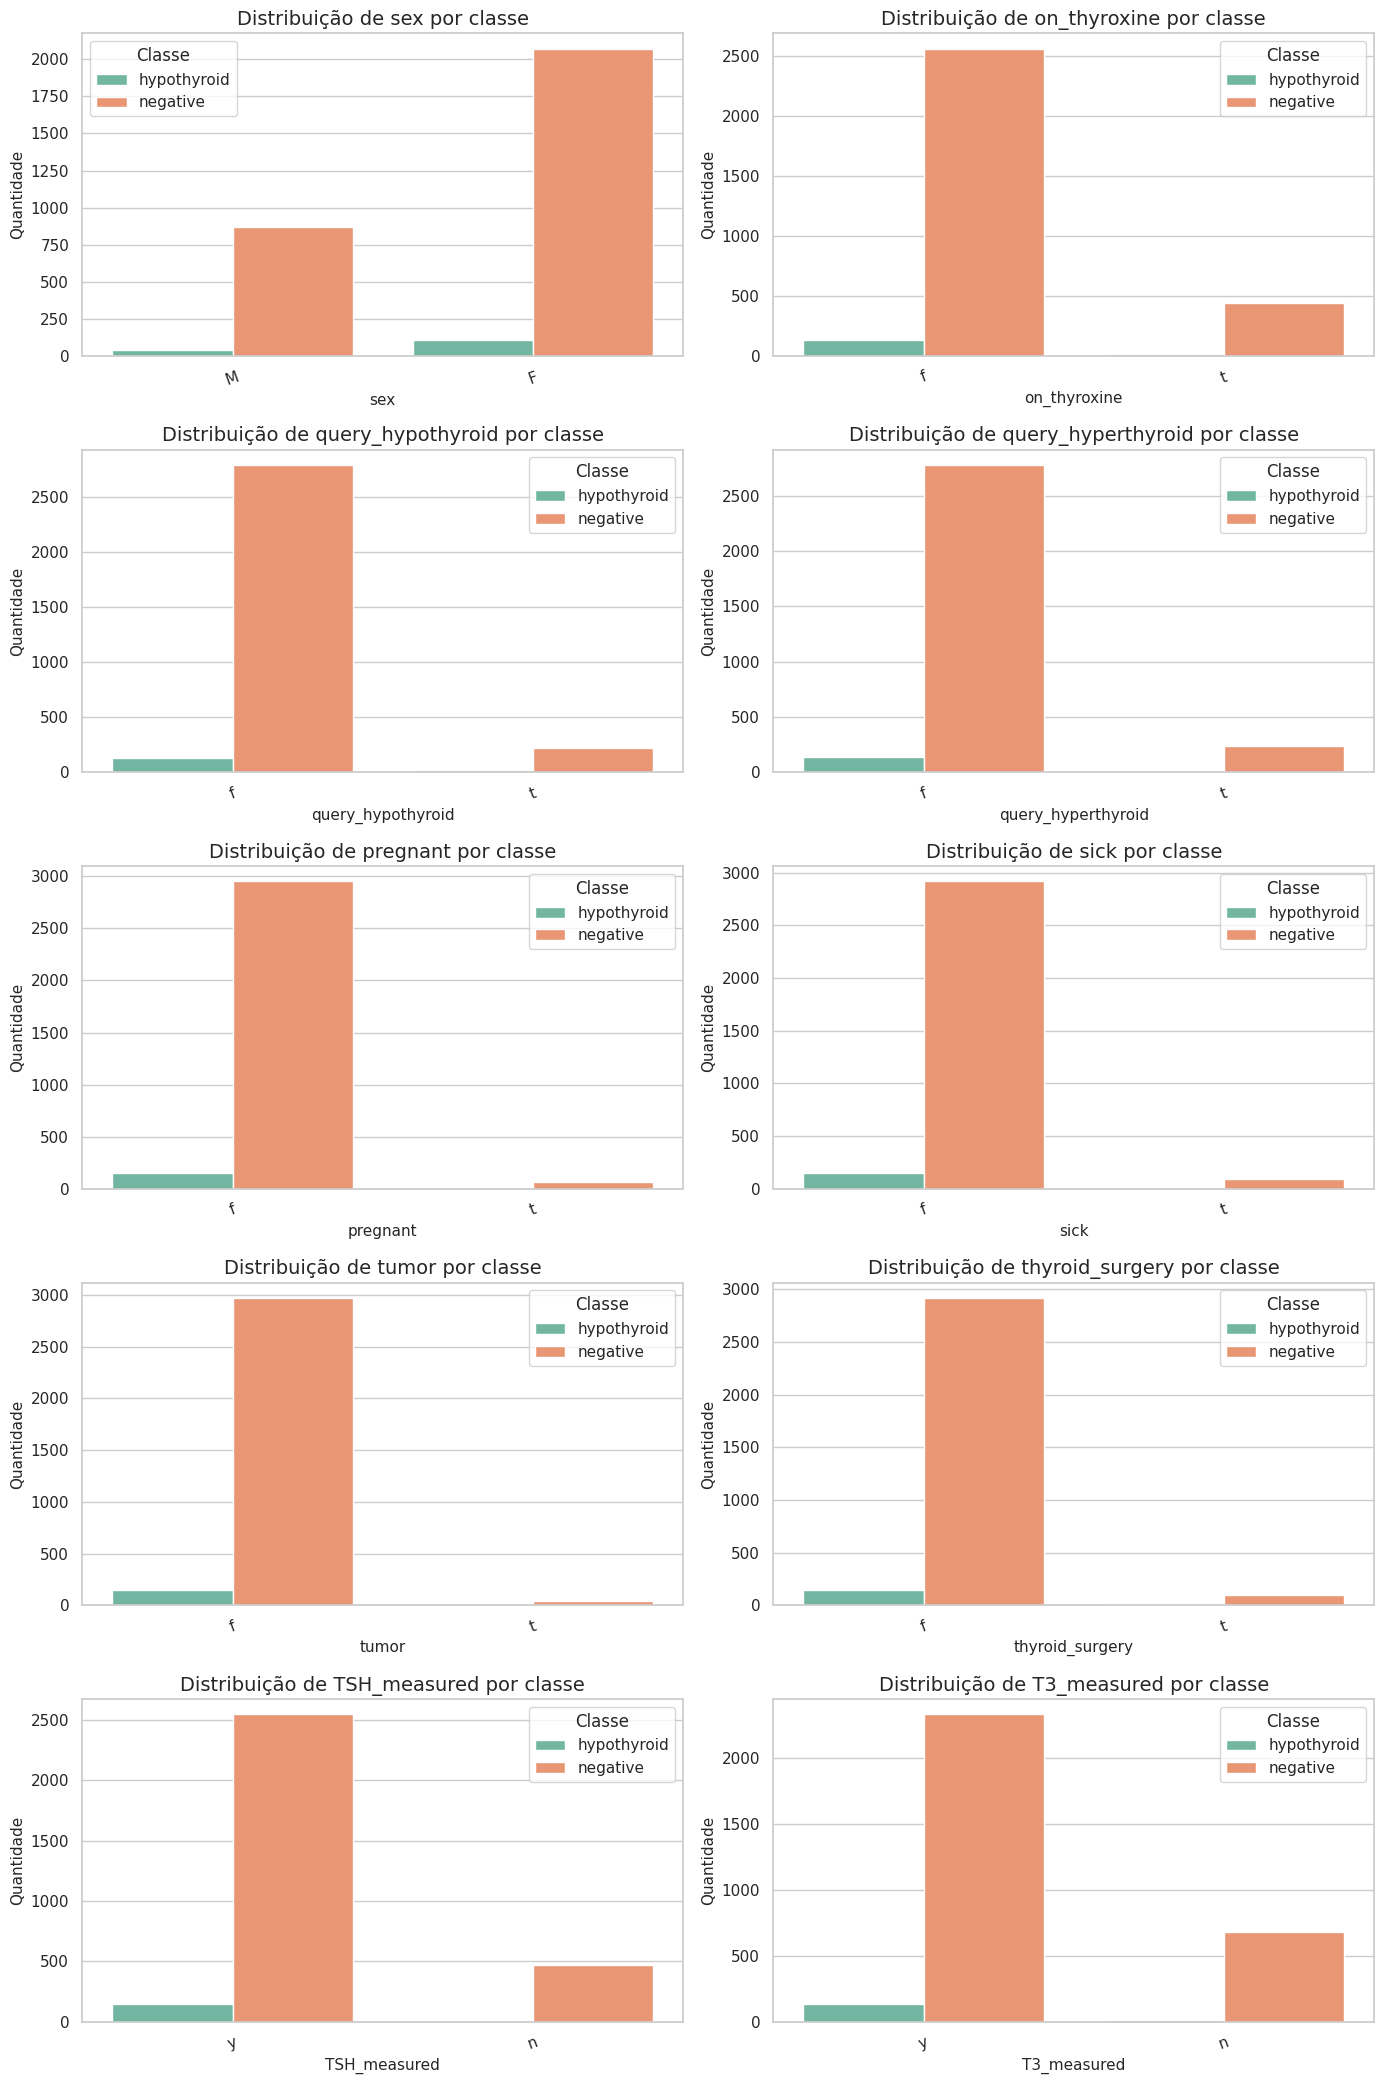

In [14]:
selected_categorical = [
    col for col in [
        "sex", "on_thyroxine", "query_hypothyroid", "query_hyperthyroid",
        "pregnant", "sick", "tumor", "thyroid_surgery", "TSH_measured", "T3_measured"
    ] if col in dados.columns
]

if selected_categorical:
    n_cols = 2
    n_rows = int(np.ceil(len(selected_categorical) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.2 * n_rows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, selected_categorical):
        sns.countplot(data=dados, x=col, hue=TARGET_COLUMN, ax=ax)
        ax.set_title(f"Distribuição de {col} por classe")
        ax.set_xlabel(col)
        ax.set_ylabel("Quantidade")
        ax.tick_params(axis="x", rotation=20)
        ax.legend(title="Classe")
    for ax in axes[len(selected_categorical):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

,categoria,classe,percentual,variavel
0,F,hypothyroid,5.087076,sex
1,M,hypothyroid,4.185022,sex
2,F,negative,94.912924,sex
3,M,negative,95.814978,sex
4,f,hypothyroid,5.070318,on_thyroxine
5,t,hypothyroid,3.036876,on_thyroxine
6,f,negative,94.929682,on_thyroxine
7,t,negative,96.963124,on_thyroxine
8,f,hypothyroid,4.483231,query_hypothyroid
9,t,hypothyroid,8.298755,query_hypothyroid


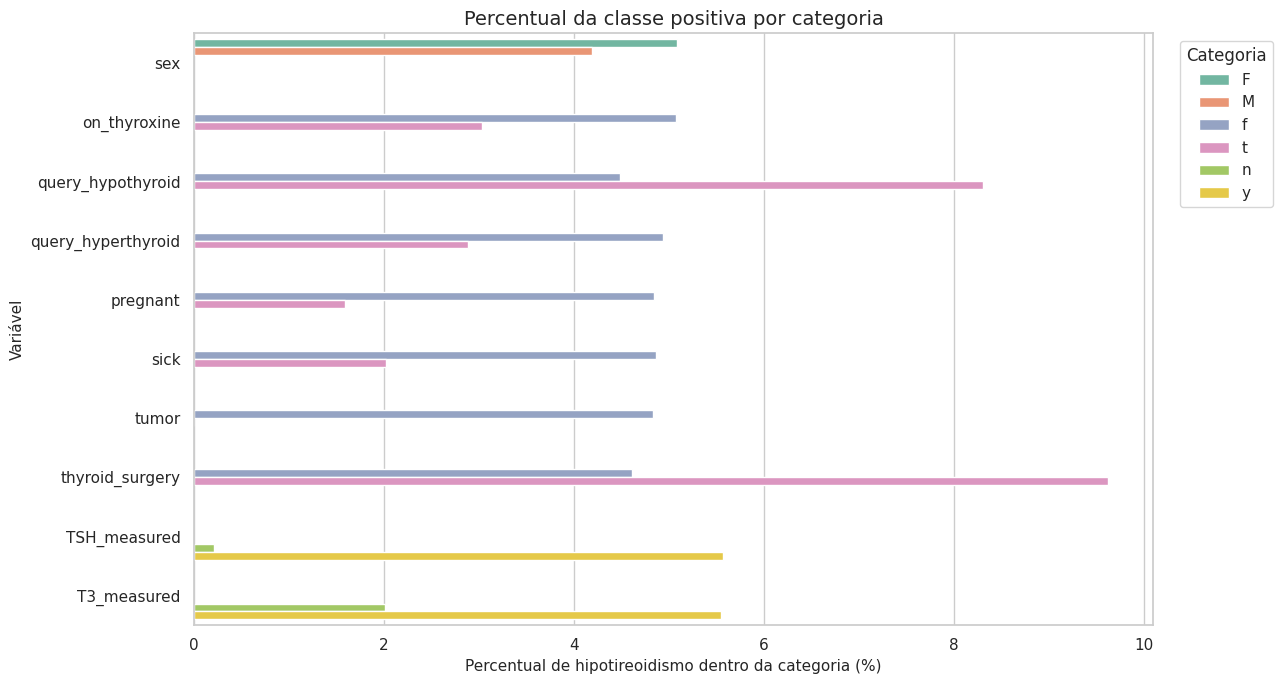

In [15]:
if selected_categorical:
    percent_frames = []
    for col in selected_categorical:
        temp = (
            pd.crosstab(dados[col], dados[TARGET_COLUMN], normalize="index")
            .mul(100)
            .reset_index()
            .melt(id_vars=col, var_name="classe", value_name="percentual")
            .rename(columns={col: "categoria"})
        )
        temp["variavel"] = col
        percent_frames.append(temp)

    categorical_percent = pd.concat(percent_frames, ignore_index=True)
    display(categorical_percent.head(20))

    plt.figure(figsize=(13, 7))
    plot_data = categorical_percent[categorical_percent["classe"] == POSITIVE_LABEL]
    sns.barplot(data=plot_data, x="percentual", y="variavel", hue="categoria")
    plt.title("Percentual da classe positiva por categoria")
    plt.xlabel("Percentual de hipotireoidismo dentro da categoria (%)")
    plt.ylabel("Variável")
    plt.legend(title="Categoria", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

As comparações categóricas indicam como características clínicas e indicadores de exames medidos se distribuem entre as classes. As diferenças observadas devem ser entendidas como associações exploratórias, não como evidência causal.

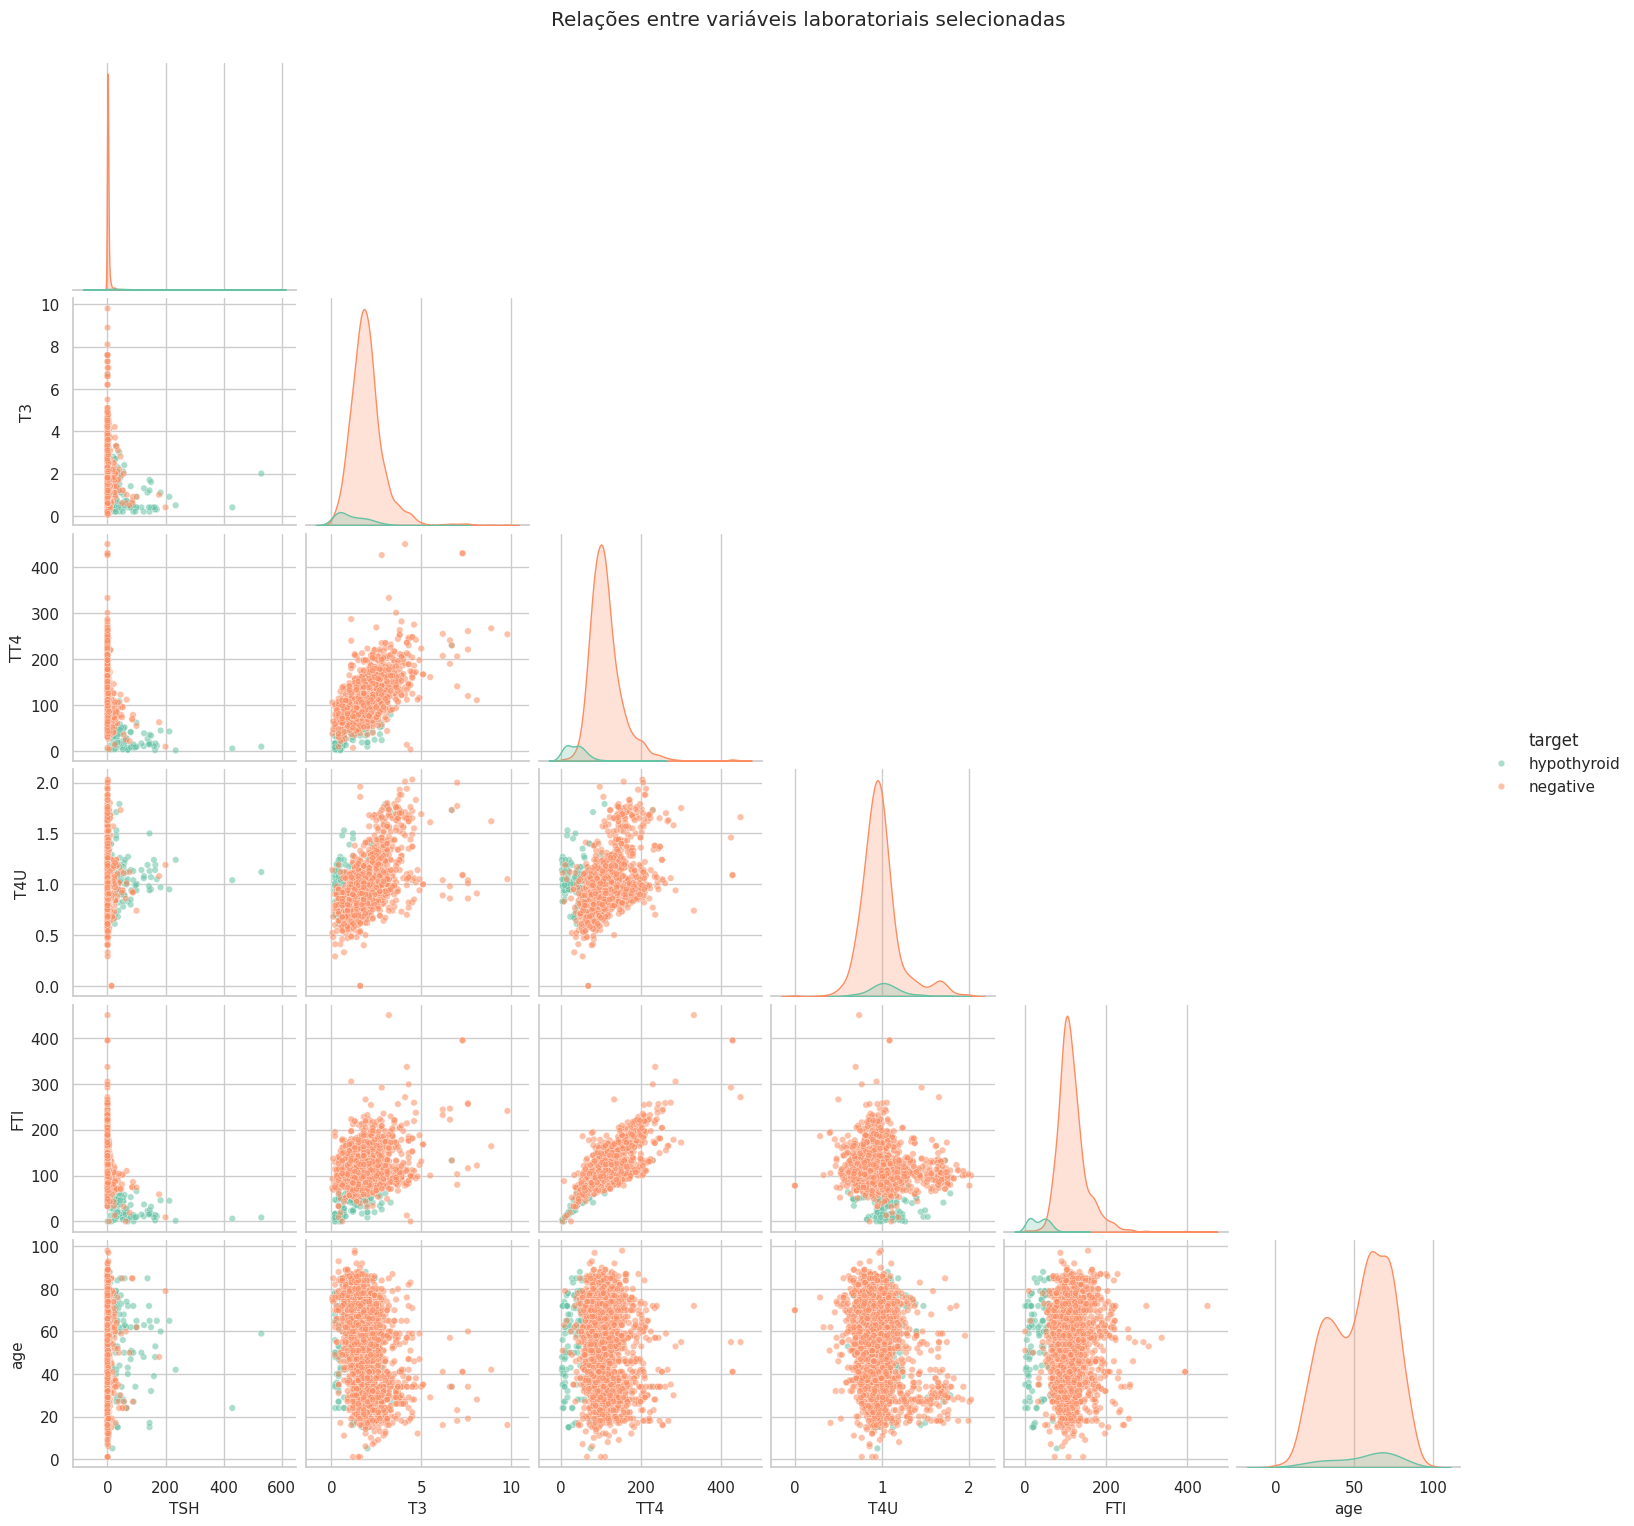

In [16]:
scatter_features = [col for col in ["TSH", "T3", "TT4", "T4U", "FTI", "age"] if col in dados.columns]

if len(scatter_features) >= 2:
    sns.pairplot(
        dados[[TARGET_COLUMN] + scatter_features].dropna(),
        hue=TARGET_COLUMN,
        diag_kind="kde",
        corner=True,
        plot_kws={"alpha": 0.55, "s": 22},
    )
    plt.suptitle("Relações entre variáveis laboratoriais selecionadas", y=1.02)
    plt.show()

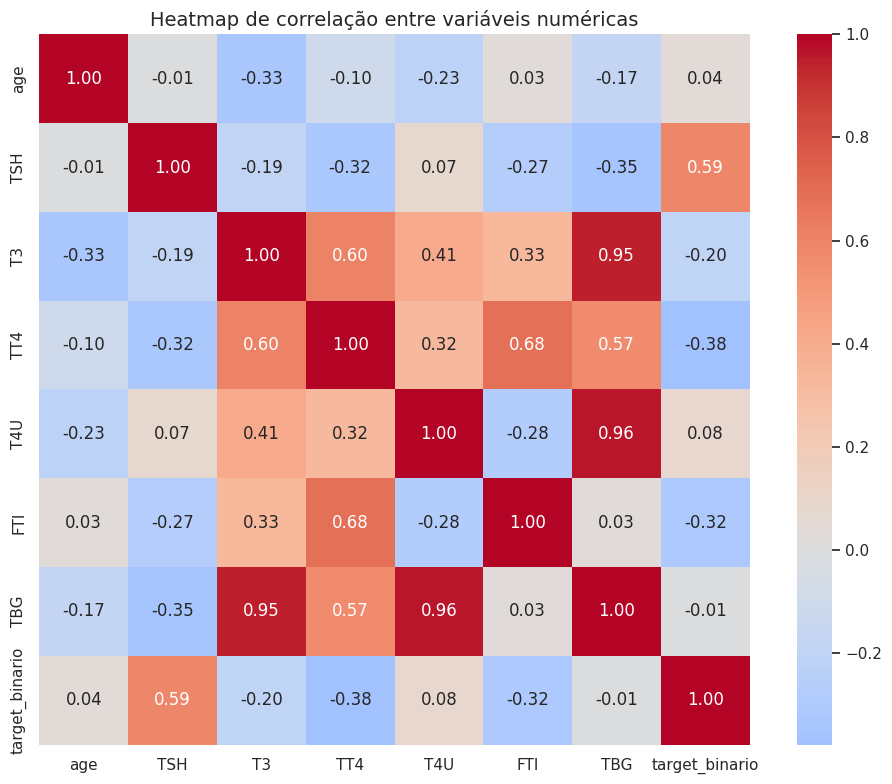

,correlacao_com_alvo
TSH,0.586390
TT4,-0.377388
FTI,-0.316932
T3,-0.196647
T4U,0.081323
age,0.037363
TBG,-0.007225


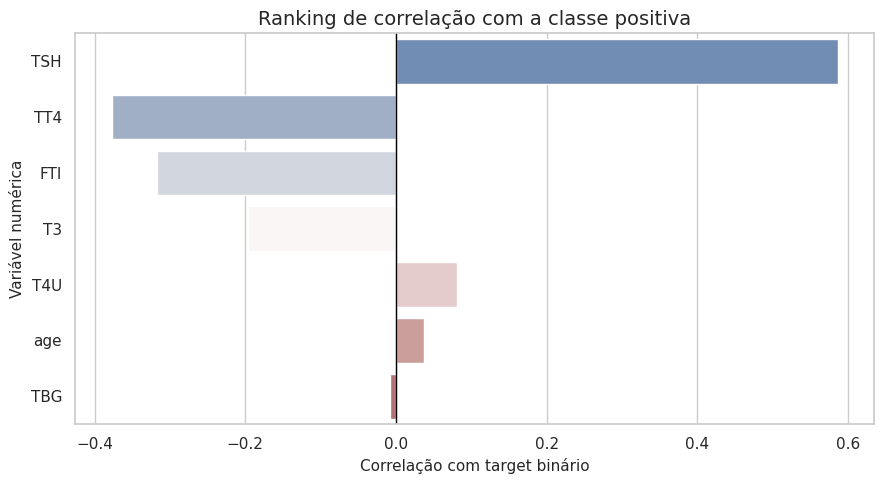

In [17]:
correlation_data = dados.copy()
correlation_data["target_binario"] = correlation_data[TARGET_COLUMN].map({NEGATIVE_LABEL: 0, POSITIVE_LABEL: 1})
corr_columns = numeric_columns + ["target_binario"]
corr_matrix = correlation_data[corr_columns].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Heatmap de correlação entre variáveis numéricas")
plt.tight_layout()
plt.show()

corr_target = (
    corr_matrix["target_binario"]
    .drop("target_binario")
    .dropna()
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
display(corr_target.to_frame("correlacao_com_alvo"))

plt.figure(figsize=(9, 5))
sns.barplot(x=corr_target.values, y=corr_target.index, palette="vlag")
plt.axvline(0, color="black", linewidth=1)
plt.title("Ranking de correlação com a classe positiva")
plt.xlabel("Correlação com target binário")
plt.ylabel("Variável numérica")
plt.tight_layout()
plt.show()

A matriz de correlação resume associações lineares entre variáveis numéricas e a classe positiva codificada. Embora esse diagnóstico seja útil para orientar a interpretação inicial, relações clínicas podem ser não lineares e dependentes de interações entre atributos.

## 6. Limpeza dos Dados

A limpeza adotou uma postura conservadora, adequada ao contexto médico. Registros duplicados foram removidos para reduzir viés amostral, enquanto valores extremos foram mantidos por sua possível relevância clínica. O tratamento de ausentes foi reservado ao pipeline de modelagem.

In [18]:
dados_limpos = dados.copy()
antes = len(dados_limpos)
dados_limpos = dados_limpos.drop_duplicates().reset_index(drop=True)
depois = len(dados_limpos)

print(f"Registros antes: {antes}")
print(f"Registros após remoção de duplicados: {depois}")
print(f"Duplicados removidos: {antes - depois}")

dados_limpos = dados_limpos[dados_limpos[TARGET_COLUMN].isin([NEGATIVE_LABEL, POSITIVE_LABEL])].reset_index(drop=True)

print("Distribuição após limpeza:")
display(dados_limpos[TARGET_COLUMN].value_counts().to_frame("quantidade"))

Registros antes: 3163
Registros após remoção de duplicados: 3086
Duplicados removidos: 77
Distribuição após limpeza:


,quantidade
target,
negative,2945
hypothyroid,141


In [19]:
checks = []
if "age" in dados_limpos.columns:
    checks.append({
        "variavel": "age",
        "menor_que_zero": int((dados_limpos["age"] < 0).sum()),
        "maior_que_120": int((dados_limpos["age"] > 120).sum()),
    })

for col in ["TSH", "T3", "TT4", "T4U", "FTI", "TBG"]:
    if col in dados_limpos.columns:
        checks.append({
            "variavel": col,
            "menor_que_zero": int((dados_limpos[col] < 0).sum()),
            "maior_que_120": np.nan,
        })

display(pd.DataFrame(checks))

,variavel,menor_que_zero,maior_que_120
0,age,0,0.0
1,TSH,0,NaN
2,T3,0,NaN
3,TT4,0,NaN
4,T4U,0,NaN
5,FTI,0,NaN
6,TBG,0,NaN


Após a remoção de duplicados, a base permanece com a estrutura necessária para modelagem supervisionada. A decisão de manter outliers evita a exclusão indevida de casos potencialmente importantes do ponto de vista clínico.

## 7. Separação entre Variáveis Preditoras e Variável-Alvo

As variáveis preditoras correspondem aos atributos disponíveis para estimar a classe do registro. A variável-alvo representa o desfecho de interesse. A separação entre `X` e `y` formaliza o problema supervisionado e prepara os dados para treinamento e avaliação dos modelos.

In [20]:
X = dados_limpos.drop(columns=[TARGET_COLUMN])
y = dados_limpos[TARGET_COLUMN].map({NEGATIVE_LABEL: 0, POSITIVE_LABEL: 1})

print(f"Formato de X: {X.shape}")
print(f"Formato de y: {y.shape}")
print("Mapeamento: 0 = negative, 1 = hypothyroid")
display(y.value_counts().rename(index={0: NEGATIVE_LABEL, 1: POSITIVE_LABEL}).to_frame("quantidade"))

Formato de X: (3086, 25)
Formato de y: (3086,)
Mapeamento: 0 = negative, 1 = hypothyroid


,quantidade
target,
negative,2945
hypothyroid,141


## 8. Separação em Treino, Validação e Teste

A base foi dividida em 70% para treino, 15% para validação e 15% para teste, com estratificação para preservar a proporção entre classes. O conjunto de validação será utilizado para comparação e escolha do modelo; o teste ficará reservado para a estimativa final de generalização.

In [21]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

splits_summary = pd.DataFrame({
    "conjunto": ["treino", "validação", "teste"],
    "quantidade": [len(X_train), len(X_val), len(X_test)],
    "percentual": [len(X_train)/len(X), len(X_val)/len(X), len(X_test)/len(X)],
    "positivos": [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
})
splits_summary["percentual"] = (splits_summary["percentual"] * 100).round(2)
display(splits_summary)

,conjunto,quantidade,percentual,positivos
0,treino,2160,69.99,99
1,validação,463,15.00,21
2,teste,463,15.00,21


## 9. Pipeline de Pré-processamento

O pré-processamento foi encapsulado em pipelines do `scikit-learn` para reduzir risco de data leakage. Assim, imputação, padronização e codificação categórica são ajustadas somente no conjunto de treino e aplicadas de forma consistente aos demais subconjuntos.

In [22]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Variáveis numéricas:", numeric_features)
print("Variáveis categóricas:", categorical_features)

def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor(scale_numeric=True):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_transformer = Pipeline(numeric_steps)
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_one_hot_encoder()),
    ])

    return ColumnTransformer([
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ])

Variáveis numéricas: ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI', 'TBG']
Variáveis categóricas: ['sex', 'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_medication', 'thyroid_surgery', 'query_hypothyroid', 'query_hyperthyroid', 'pregnant', 'sick', 'tumor', 'lithium', 'goitre', 'TSH_measured', 'T3_measured', 'TT4_measured', 'T4U_measured', 'FTI_measured', 'TBG_measured']


## 10. Modelagem

Foram avaliadas três abordagens de classificação: Regressão Logística, Random Forest e HistGradientBoostingClassifier. A Regressão Logística funciona como baseline interpretável; a Random Forest captura relações não lineares; e o modelo de boosting incorpora `early_stopping`, interrompendo o treinamento quando não há ganho consistente na validação interna.

In [23]:
modelos = {
    "Regressão Logística": Pipeline([
        ("preprocessor", build_preprocessor(scale_numeric=True)),
        ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", build_preprocessor(scale_numeric=False)),
        ("classifier", RandomForestClassifier(
            n_estimators=400, min_samples_leaf=2, class_weight="balanced_subsample",
            random_state=RANDOM_STATE, n_jobs=-1
        )),
    ]),
    "HistGradientBoosting com Early Stopping": Pipeline([
        ("preprocessor", build_preprocessor(scale_numeric=False)),
        ("classifier", HistGradientBoostingClassifier(
            max_iter=300, learning_rate=0.05, max_leaf_nodes=31,
            early_stopping=True, validation_fraction=0.15,
            n_iter_no_change=15, random_state=RANDOM_STATE
        )),
    ]),
}

In [24]:
def get_positive_scores(model, X_data):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X_data)
    return None


def evaluate_model(model, X_data, y_true):
    y_pred = model.predict(X_data)
    y_score = get_positive_scores(model, X_data)
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_score) if y_score is not None else np.nan,
    }
    return metrics, y_pred, y_score


def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=[NEGATIVE_LABEL, POSITIVE_LABEL],
        yticklabels=[NEGATIVE_LABEL, POSITIVE_LABEL],
    )
    plt.title(title)
    plt.xlabel("Classe prevista")
    plt.ylabel("Classe real")
    plt.tight_layout()
    plt.show()

In [25]:
resultados = []
modelos_treinados = {}
validacao_predicoes = {}

for nome, pipeline in modelos.items():
    print(f"Treinando: {nome}")
    pipeline.fit(X_train, y_train)
    modelos_treinados[nome] = pipeline

    train_metrics, _, _ = evaluate_model(pipeline, X_train, y_train)
    val_metrics, y_val_pred, y_val_score = evaluate_model(pipeline, X_val, y_val)
    validacao_predicoes[nome] = {"pred": y_val_pred, "score": y_val_score}

    classifier = pipeline.named_steps["classifier"]
    resultados.append({
        "modelo": nome,
        "accuracy_treino": train_metrics["accuracy"],
        "recall_treino": train_metrics["recall"],
        "f1_treino": train_metrics["f1"],
        "accuracy_validacao": val_metrics["accuracy"],
        "precision_validacao": val_metrics["precision"],
        "recall_validacao": val_metrics["recall"],
        "f1_validacao": val_metrics["f1"],
        "auc_validacao": val_metrics["auc"],
        "iteracoes_usadas": getattr(classifier, "n_iter_", np.nan),
    })

resultados_df = pd.DataFrame(resultados).sort_values(
    by=["recall_validacao", "f1_validacao", "auc_validacao"],
    ascending=False,
).reset_index(drop=True)

display(resultados_df.style.format({col: "{:.3f}" for col in resultados_df.select_dtypes(include=[np.number]).columns}))

Treinando: Regressão Logística
Treinando: Random Forest
Treinando: HistGradientBoosting com Early Stopping


,modelo,accuracy_treino,recall_treino,f1_treino,accuracy_validacao,precision_validacao,recall_validacao,f1_validacao,auc_validacao,iteracoes_usadas
0,Random Forest,0.994,1.000,0.934,0.991,0.870,0.952,0.909,0.986,nan
1,Regressão Logística,0.968,0.990,0.737,0.972,0.625,0.952,0.755,0.954,[61]
2,HistGradientBoosting com Early Stopping,0.997,0.949,0.969,0.989,0.900,0.857,0.878,0.954,95


## 11. Avaliação dos Modelos

A avaliação considera accuracy, precision, recall, F1-score, matriz de confusão, curva ROC e AUC. Em contexto clínico, recall recebe atenção especial, pois falsos negativos podem deixar de sinalizar pacientes possivelmente doentes. A análise também considera falsos positivos, que podem gerar exames adicionais, custos e ansiedade.

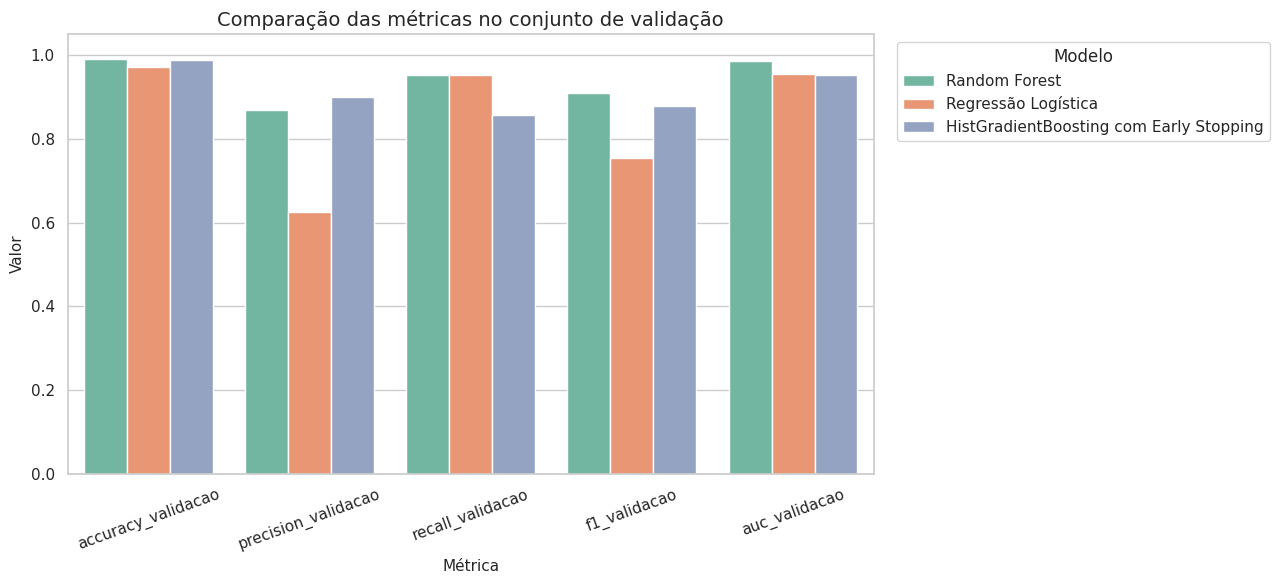

In [26]:
metrics_long = resultados_df.melt(
    id_vars="modelo",
    value_vars=["accuracy_validacao", "precision_validacao", "recall_validacao", "f1_validacao", "auc_validacao"],
    var_name="metrica",
    value_name="valor",
)

plt.figure(figsize=(13, 6))
sns.barplot(data=metrics_long, x="metrica", y="valor", hue="modelo")
plt.title("Comparação das métricas no conjunto de validação")
plt.xlabel("Métrica")
plt.ylabel("Valor")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.legend(title="Modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Regressão Logística
              precision    recall  f1-score   support

    negative       1.00      0.97      0.99       442
 hypothyroid       0.62      0.95      0.75        21

    accuracy                           0.97       463
   macro avg       0.81      0.96      0.87       463
weighted avg       0.98      0.97      0.97       463



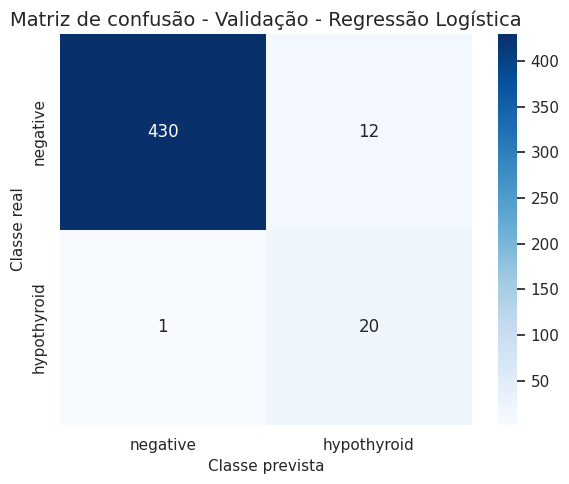

Random Forest
              precision    recall  f1-score   support

    negative       1.00      0.99      1.00       442
 hypothyroid       0.87      0.95      0.91        21

    accuracy                           0.99       463
   macro avg       0.93      0.97      0.95       463
weighted avg       0.99      0.99      0.99       463



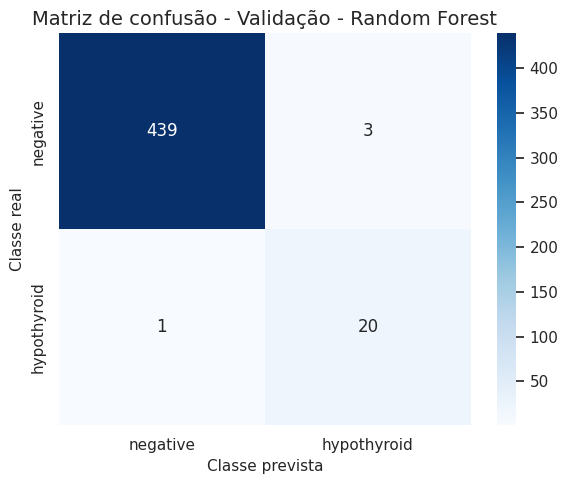

HistGradientBoosting com Early Stopping
              precision    recall  f1-score   support

    negative       0.99      1.00      0.99       442
 hypothyroid       0.90      0.86      0.88        21

    accuracy                           0.99       463
   macro avg       0.95      0.93      0.94       463
weighted avg       0.99      0.99      0.99       463



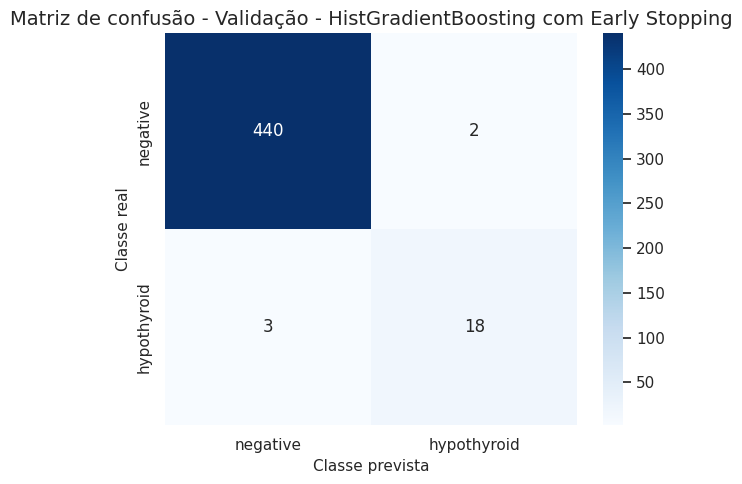

In [27]:
for nome, valores in validacao_predicoes.items():
    print("=" * 80)
    print(nome)
    print(classification_report(y_val, valores["pred"], target_names=[NEGATIVE_LABEL, POSITIVE_LABEL], zero_division=0))
    plot_confusion_matrix(y_val, valores["pred"], f"Matriz de confusão - Validação - {nome}")

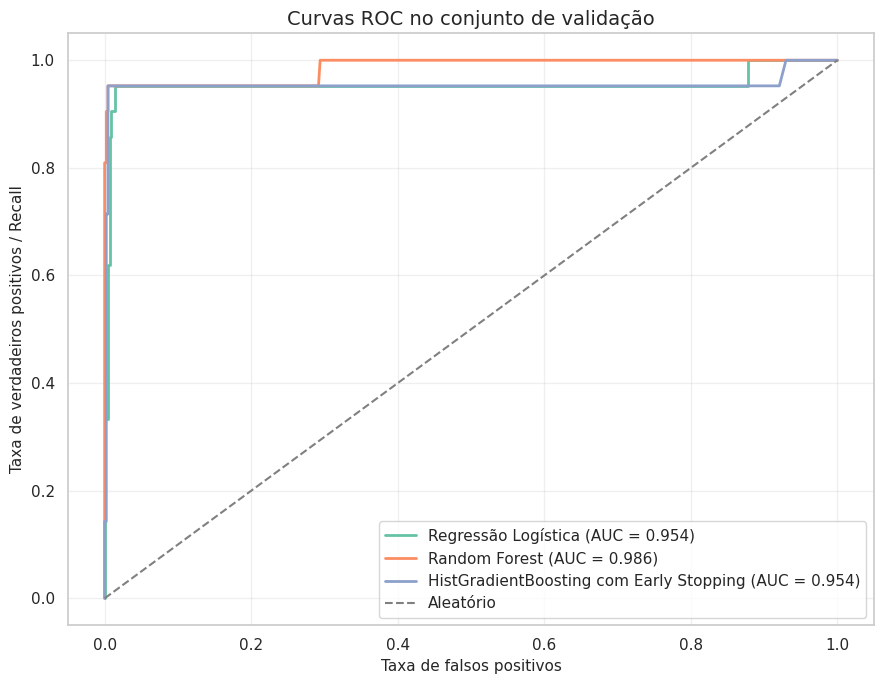

In [28]:
plt.figure(figsize=(9, 7))
for nome, valores in validacao_predicoes.items():
    y_score = valores["score"]
    if y_score is None:
        continue
    fpr, tpr, _ = roc_curve(y_val, y_score)
    model_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f"{nome} (AUC = {model_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório")
plt.title("Curvas ROC no conjunto de validação")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos / Recall")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

As matrizes de confusão detalham a natureza dos erros cometidos pelos modelos. As curvas ROC complementam a análise ao mostrar a capacidade de separação entre classes em diferentes limiares de decisão. Em uma base desbalanceada, esses recursos são mais informativos que a acurácia isolada.

## 12. Early Stopping e Análise de Overfitting

O early stopping foi aplicado ao modelo de boosting para monitorar a evolução do treinamento e interromper novas iterações quando a validação interna deixa de apresentar melhora relevante. Curvas de aprendizado e validação foram incluídas para comparar desempenho em treino e validação e identificar indícios de overfitting.

Iterações máximas configuradas: 300
Iterações efetivamente usadas: 95
Early stopping ativado: True


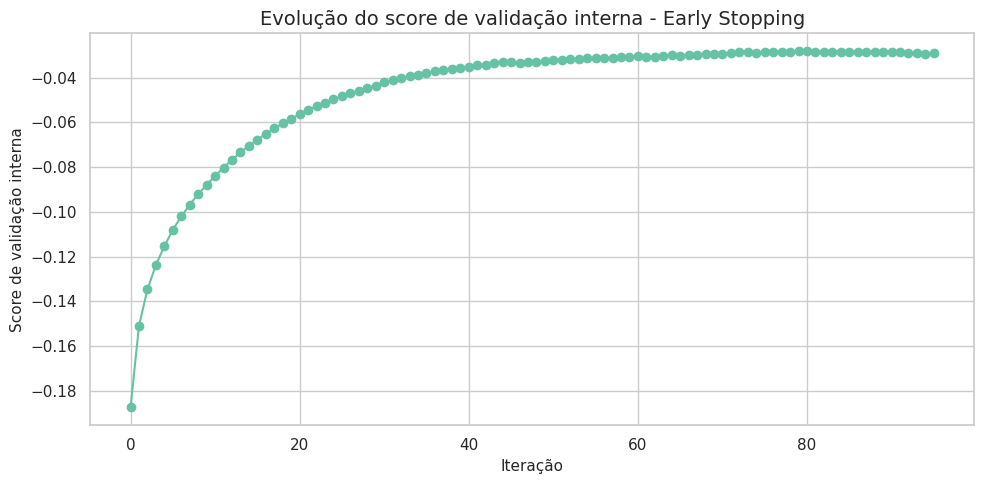

In [29]:
hgb_model = modelos_treinados["HistGradientBoosting com Early Stopping"].named_steps["classifier"]

print(f"Iterações máximas configuradas: {hgb_model.max_iter}")
print(f"Iterações efetivamente usadas: {hgb_model.n_iter_}")
print(f"Early stopping ativado: {hgb_model.early_stopping}")

if hasattr(hgb_model, "validation_score_") and hgb_model.validation_score_ is not None:
    plt.figure(figsize=(10, 5))
    plt.plot(hgb_model.validation_score_, marker="o")
    plt.title("Evolução do score de validação interna - Early Stopping")
    plt.xlabel("Iteração")
    plt.ylabel("Score de validação interna")
    plt.tight_layout()
    plt.show()
else:
    print("O modelo não expôs validation_score_. n_iter_ ainda indica o ponto de parada.")

Gerando learning curve para: Regressão Logística


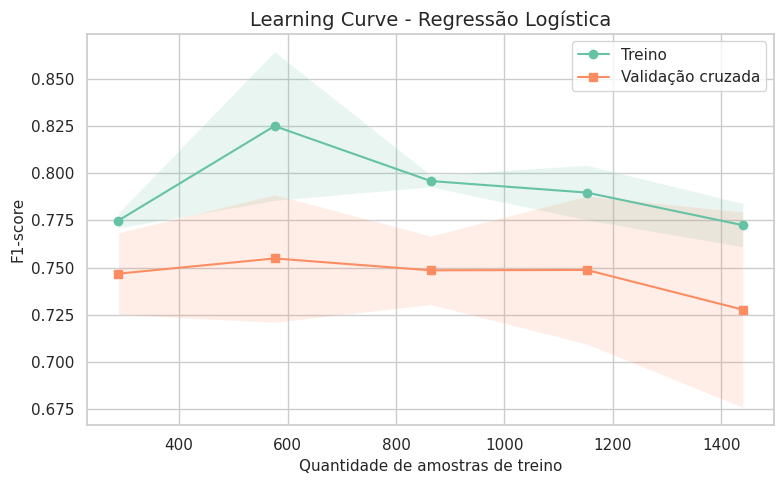

Gerando learning curve para: Random Forest


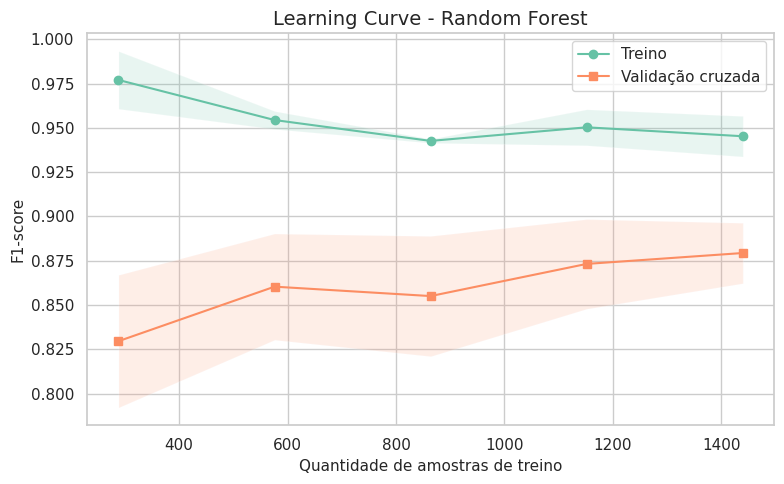

Gerando learning curve para: HistGradientBoosting com Early Stopping


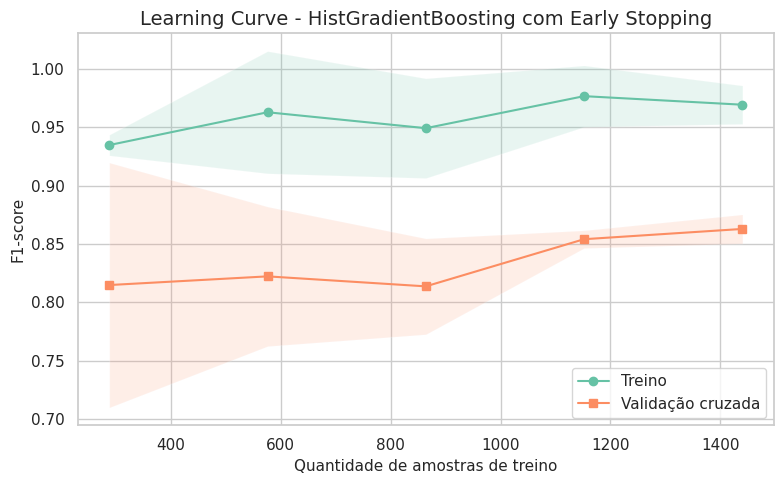

In [30]:
for nome, modelo in modelos_treinados.items():
    print(f"Gerando learning curve para: {nome}")
    train_sizes, train_scores, val_scores = learning_curve(
        modelo, X_train, y_train, cv=3, scoring="f1",
        train_sizes=np.linspace(0.2, 1.0, 5), n_jobs=-1
    )

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Treino")
    plt.plot(train_sizes, val_scores.mean(axis=1), marker="s", label="Validação cruzada")
    plt.fill_between(train_sizes, train_scores.mean(axis=1)-train_scores.std(axis=1), train_scores.mean(axis=1)+train_scores.std(axis=1), alpha=0.15)
    plt.fill_between(train_sizes, val_scores.mean(axis=1)-val_scores.std(axis=1), val_scores.mean(axis=1)+val_scores.std(axis=1), alpha=0.15)
    plt.title(f"Learning Curve - {nome}")
    plt.xlabel("Quantidade de amostras de treino")
    plt.ylabel("F1-score")
    plt.legend()
    plt.tight_layout()
    plt.show()

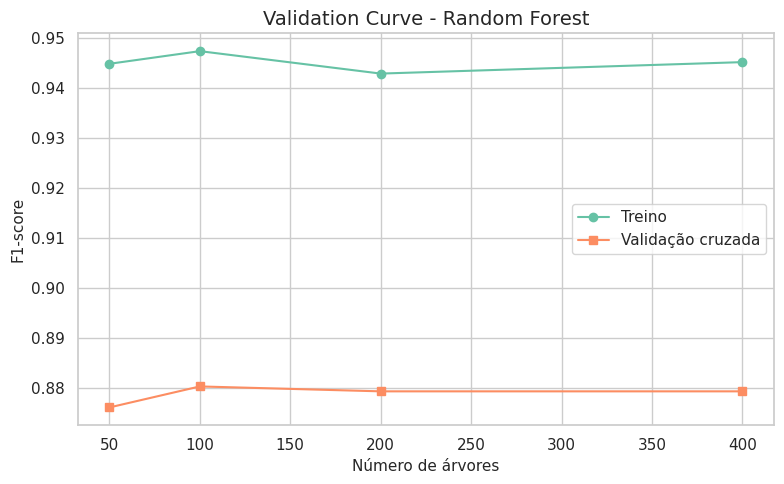

In [31]:
rf_pipeline = modelos["Random Forest"]
param_range = [50, 100, 200, 400]
train_scores, val_scores = validation_curve(
    rf_pipeline, X_train, y_train,
    param_name="classifier__n_estimators",
    param_range=param_range, cv=3, scoring="f1", n_jobs=-1
)

plt.figure(figsize=(8, 5))
plt.plot(param_range, train_scores.mean(axis=1), marker="o", label="Treino")
plt.plot(param_range, val_scores.mean(axis=1), marker="s", label="Validação cruzada")
plt.title("Validation Curve - Random Forest")
plt.xlabel("Número de árvores")
plt.ylabel("F1-score")
plt.legend()
plt.tight_layout()
plt.show()

Diferenças expressivas entre desempenho de treino e validação indicam possível overfitting. Quando ambos os desempenhos são baixos, pode haver limitação de capacidade preditiva ou necessidade de melhor representação dos dados. O early stopping atua como mecanismo adicional de controle para modelos iterativos.

## 13. Escolha do Melhor Modelo

A seleção do modelo foi realizada exclusivamente com base no conjunto de validação. Os critérios priorizam recall, F1-score, AUC e estabilidade entre treino e validação, considerando o uso pretendido como apoio à triagem clínica.

In [32]:
resultados_df["gap_f1_treino_validacao"] = (resultados_df["f1_treino"] - resultados_df["f1_validacao"]).abs()

ranking = resultados_df.sort_values(
    by=["recall_validacao", "f1_validacao", "auc_validacao", "gap_f1_treino_validacao"],
    ascending=[False, False, False, True],
).reset_index(drop=True)

display(ranking.style.format({col: "{:.3f}" for col in ranking.select_dtypes(include=[np.number]).columns}))

best_model_name = ranking.loc[0, "modelo"]
best_model = modelos_treinados[best_model_name]
print(f"Melhor modelo selecionado: {best_model_name}")

,modelo,accuracy_treino,recall_treino,f1_treino,accuracy_validacao,precision_validacao,recall_validacao,f1_validacao,auc_validacao,iteracoes_usadas,gap_f1_treino_validacao
0,Random Forest,0.994,1.000,0.934,0.991,0.870,0.952,0.909,0.986,nan,0.025
1,Regressão Logística,0.968,0.990,0.737,0.972,0.625,0.952,0.755,0.954,[61],0.018
2,HistGradientBoosting com Early Stopping,0.997,0.949,0.969,0.989,0.900,0.857,0.878,0.954,95,0.091


Melhor modelo selecionado: Random Forest


## 14. Avaliação Final no Conjunto de Teste

Após a escolha do modelo, o conjunto de teste foi utilizado para estimar desempenho em dados não vistos. Essa separação reduz otimismo indevido nas métricas finais e fornece uma aproximação mais honesta da capacidade de generalização.

,valor
accuracy,0.991
precision,0.905
recall,0.905
f1,0.905
auc,0.996


Classification report final:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       442
 hypothyroid       0.90      0.90      0.90        21

    accuracy                           0.99       463
   macro avg       0.95      0.95      0.95       463
weighted avg       0.99      0.99      0.99       463



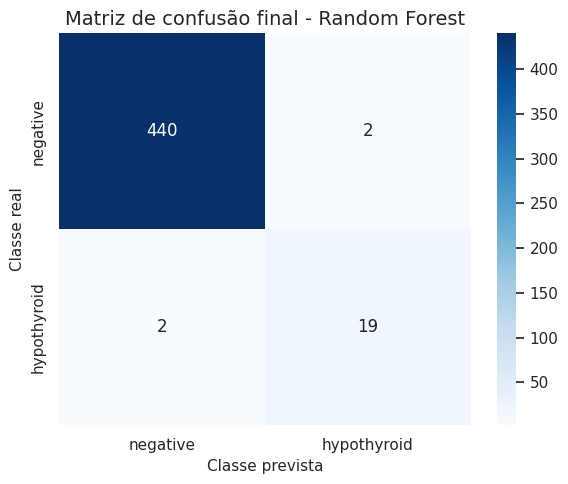

In [33]:
test_metrics, y_test_pred, y_test_score = evaluate_model(best_model, X_test, y_test)
test_results = pd.DataFrame([test_metrics], index=[best_model_name]).T.rename(columns={best_model_name: "valor"})
display(test_results.style.format("{:.3f}"))

print("Classification report final:")
print(classification_report(y_test, y_test_pred, target_names=[NEGATIVE_LABEL, POSITIVE_LABEL], zero_division=0))

plot_confusion_matrix(y_test, y_test_pred, f"Matriz de confusão final - {best_model_name}")

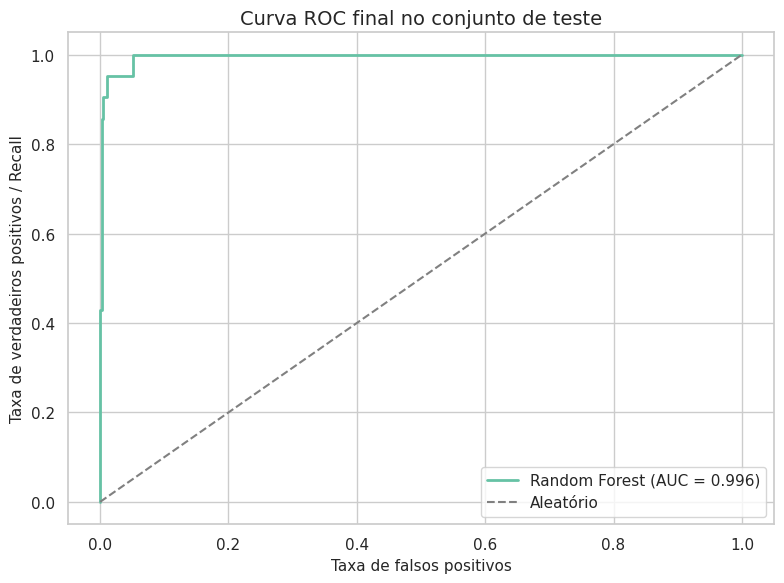

In [34]:
if y_test_score is not None:
    fpr, tpr, _ = roc_curve(y_test, y_test_score)
    test_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, linewidth=2, label=f"{best_model_name} (AUC = {test_auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório")
    plt.title("Curva ROC final no conjunto de teste")
    plt.xlabel("Taxa de falsos positivos")
    plt.ylabel("Taxa de verdadeiros positivos / Recall")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
else:
    print("Modelo sem score probabilístico disponível para ROC.")

## 15. Interpretação do Modelo

A interpretação considera importância por permutação, coeficientes quando aplicável e SHAP de forma opcional. O objetivo é identificar variáveis com maior influência nas previsões, mantendo a ressalva de que importância estatística não implica causalidade clínica.

,variavel,importancia_media,importancia_desvio
22,FTI,0.759050,0.055643
14,TSH,0.282852,0.027688
18,TT4,0.143971,0.042347
0,age,0.023897,0.014407
2,on_thyroxine,0.016162,0.008081
20,T4U,0.012550,0.013621
1,sex,0.010101,0.010101
15,T3_measured,0.004040,0.008081
7,query_hyperthyroid,0.002020,0.006061
12,goitre,0.002020,0.006061


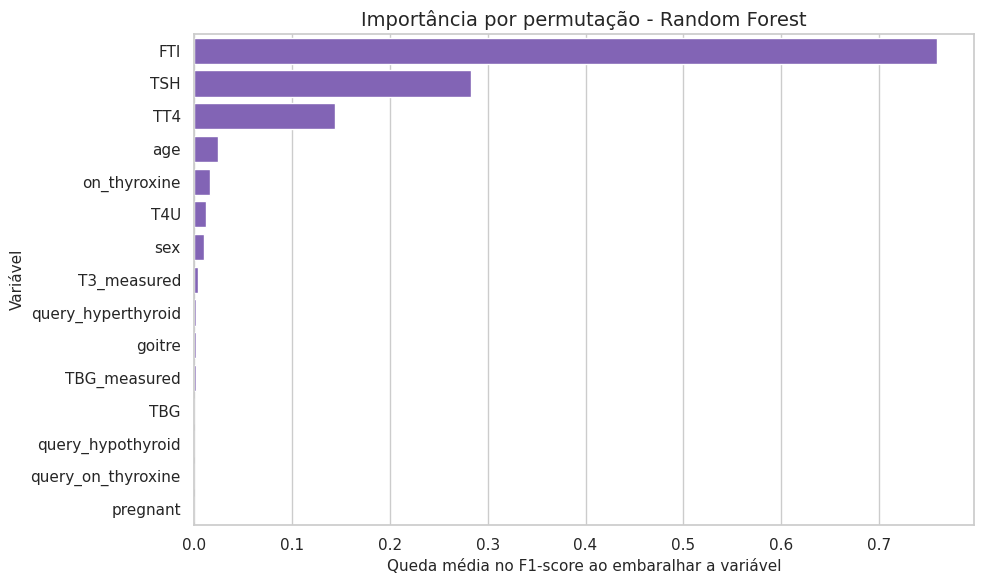

In [35]:
preprocessor = best_model.named_steps["preprocessor"]
classifier = best_model.named_steps["classifier"]

perm_importance = permutation_importance(
    best_model, X_val, y_val, n_repeats=10,
    random_state=RANDOM_STATE, scoring="f1", n_jobs=-1
)

importance_df = pd.DataFrame({
    "variavel": X_val.columns,
    "importancia_media": perm_importance.importances_mean,
    "importancia_desvio": perm_importance.importances_std,
}).sort_values("importancia_media", ascending=False)

display(importance_df.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x="importancia_media", y="variavel", color="#7E57C2")
plt.title(f"Importância por permutação - {best_model_name}")
plt.xlabel("Queda média no F1-score ao embaralhar a variável")
plt.ylabel("Variável")
plt.tight_layout()
plt.show()

In [36]:
def get_feature_names(preprocessor):
    feature_names = []
    if numeric_features:
        feature_names.extend(numeric_features)
    if categorical_features:
        cat_pipeline = preprocessor.named_transformers_["cat"]
        encoder = cat_pipeline.named_steps["onehot"]
        feature_names.extend(encoder.get_feature_names_out(categorical_features).tolist())
    return feature_names


if isinstance(classifier, LogisticRegression):
    feature_names = get_feature_names(preprocessor)
    coefficients = pd.DataFrame({
        "atributo": feature_names,
        "coeficiente": classifier.coef_[0],
    })
    coefficients["coeficiente_abs"] = coefficients["coeficiente"].abs()
    coefficients = coefficients.sort_values("coeficiente_abs", ascending=False)
    display(coefficients.head(20))

    plt.figure(figsize=(10, 7))
    sns.barplot(data=coefficients.head(20), x="coeficiente", y="atributo", palette="vlag")
    plt.axvline(0, color="black", linewidth=1)
    plt.title("Coeficientes mais relevantes - Regressão Logística")
    plt.xlabel("Coeficiente")
    plt.ylabel("Atributo")
    plt.tight_layout()
    plt.show()
else:
    print("O melhor modelo não é Regressão Logística; coeficientes lineares não se aplicam.")

O melhor modelo não é Regressão Logística; coeficientes lineares não se aplicam.


In [37]:
try:
    import shap

    feature_names = get_feature_names(preprocessor)
    X_val_transformed = preprocessor.transform(X_val)
    sample_size = min(250, X_val_transformed.shape[0])
    X_shap = X_val_transformed[:sample_size]

    if isinstance(classifier, (RandomForestClassifier, HistGradientBoostingClassifier)):
        explainer = shap.Explainer(classifier, X_shap, feature_names=feature_names)
        shap_values = explainer(X_shap)
        shap.plots.beeswarm(shap_values, max_display=15)
    else:
        print("SHAP foi carregado, mas este bloco está configurado principalmente para modelos de árvore/boosting.")
except Exception as exc:
    print("SHAP não foi executado neste ambiente.")
    print(f"Motivo: {type(exc).__name__}: {exc}")

SHAP não foi executado neste ambiente.
Motivo: ValueError: The beeswarm plot does not support plotting explanations with instances that have more than one dimension!


As variáveis mais influentes devem ser analisadas como sinais estatísticos do modelo, não como comprovação de causa. Qualquer conclusão clínica exige validação por especialistas, avaliação de protocolos e análise do contexto de coleta dos dados.

## 16. Salvamento e Carregamento do Modelo

O pipeline final será persistido com o pré-processamento e o classificador selecionado, garantindo que futuras previsões utilizem exatamente as mesmas transformações aplicadas durante o treinamento.

In [38]:
model_path = MODELS_DIR / "modelo_classificacao_tireoide.pkl"
joblib.dump(best_model, model_path)
print(f"Modelo salvo em: {model_path.resolve()}")

Modelo salvo em: /content/TechCahllenge_Tireoide/models/modelo_classificacao_tireoide.pkl


In [39]:
modelo_carregado = joblib.load(model_path)
print("Modelo carregado com sucesso.")
print(modelo_carregado)

Modelo carregado com sucesso.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age', 'TSH', 'T3', 'TT4',
                                                   'T4U', 'FTI', 'TBG']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
             

## 17. Relatório Final e Discussão dos Resultados

Este projeto desenvolveu uma solução inicial de Machine Learning para classificação de registros clínicos relacionados à tireoide. A tarefa foi formulada como classificação binária entre hipotireoidismo e classe negativa, utilizando atributos demográficos, clínicos e laboratoriais disponíveis em formato tabular.

A análise exploratória evidenciou uma base composta por variáveis numéricas de exames e variáveis categóricas relacionadas a histórico clínico, sintomas, medicamentos e disponibilidade de medições laboratoriais. Também foi identificado desbalanceamento expressivo entre as classes, com predominância de registros negativos. Esse aspecto orientou a escolha de métricas mais adequadas ao problema, com destaque para recall e F1-score.

A etapa de limpeza removeu registros duplicados e preservou valores extremos, considerando que alterações acentuadas em exames podem possuir significado clínico. Os valores ausentes foram tratados dentro dos pipelines de modelagem, evitando que informações dos conjuntos de validação ou teste influenciassem o ajuste do pré-processamento.

Foram comparados três modelos: Regressão Logística, Random Forest e HistGradientBoostingClassifier com early stopping. A escolha do melhor modelo foi baseada no conjunto de validação, priorizando capacidade de identificar a classe positiva, equilíbrio geral das métricas e estabilidade entre treino e validação. O conjunto de teste foi reservado para a avaliação final, simulando dados não observados durante a seleção.

As visualizações de desempenho, incluindo matrizes de confusão, curvas ROC, learning curves e validation curve, permitiram analisar a qualidade preditiva e potenciais sinais de overfitting. A interpretação por importância de variáveis, coeficientes e SHAP opcional forneceu uma visão complementar sobre os fatores mais influentes nas previsões, sem atribuir causalidade às associações encontradas.

Como limitações, o estudo utiliza uma única base tabular e não contempla validação prospectiva, auditoria de vieses, calibração clínica formal, integração com prontuários reais ou avaliação regulatória. Em uso real, falsos negativos poderiam atrasar investigação clínica, enquanto falsos positivos poderiam gerar exames adicionais e preocupação desnecessária. Portanto, o modelo deve ser compreendido como apoio à triagem e análise inicial, nunca como substituto da avaliação médica.

Melhorias futuras incluem validação externa, ajuste de limiar de decisão, calibração de probabilidades, técnicas adicionais para desbalanceamento, monitoramento de drift e revisão das variáveis com especialistas clínicos. A conclusão central é que modelos supervisionados podem apoiar a organização da análise médica, desde que utilizados com governança, validação adequada e decisão final sempre conduzida por profissionais da saúde.